# Junction-aware vector reconstruction with MLP/CNN cleanup

The machine learning models are used for **junction handling**.

The pipeline is:

1. Generate random synthetic line-vector drawings.
2. Rasterise them to 128×128 black-on-white images.
3. Create a clean threshold stroke mask.
4. Train an MLP and a small CNN to predict **junction regions** from local raster patches.
5. Reconstruct vectors using:
   - baseline graph junction detection,
   - MLP-predicted junction mask,
   - CNN-predicted junction mask.
6. Compare the reconstructed vectors against the original vectors visually.

The aim is not to use ML to replace thresholding. The aim is to use ML to stop junctions creating many tiny fragments while also avoiding gaps at intersections.

In [1]:
import random
import math
from pathlib import Path
from collections import deque

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# New data every time by default.
SEED = None
if SEED is not None:
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

IMG_SIZE = 128
MAX_VECTORS = 5
LINE_WIDTH = 1

N_TRAIN_IMAGES = 600
N_TEST = 80

PATCH_SIZE = 9
PATCH_RADIUS = PATCH_SIZE // 2
JUNCTION_RADIUS = 2

BATCH_SIZE = 512
MLP_EPOCHS = 4
CNN_EPOCHS = 4
LEARNING_RATE = 1e-3

# Controls the final vector cleanup.
MIN_VECTOR_LENGTH = 2.0
MAX_MERGE_PASSES = 2

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cpu


## 1. Synthetic vector data

Each sample has between 1 and 5 random straight lines. Lines are rasterised with 1-pixel weight on a white background.

(600, 128, 128) 600


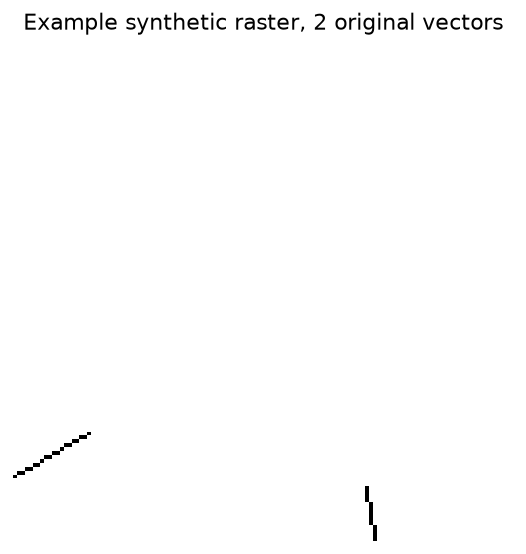

In [2]:
def clip_point(x, y, img_size=IMG_SIZE):
    return int(np.clip(round(x), 0, img_size - 1)), int(np.clip(round(y), 0, img_size - 1))


def bresenham_line(x0, y0, x1, y1):
    x0, y0, x1, y1 = map(int, [x0, y0, x1, y1])
    points = []
    dx = abs(x1 - x0)
    dy = -abs(y1 - y0)
    sx = 1 if x0 < x1 else -1
    sy = 1 if y0 < y1 else -1
    err = dx + dy
    x, y = x0, y0
    while True:
        points.append((x, y))
        if x == x1 and y == y1:
            break
        e2 = 2 * err
        if e2 >= dy:
            err += dy
            x += sx
        if e2 <= dx:
            err += dx
            y += sy
    return points


def rasterise_vectors(vectors, img_size=IMG_SIZE):
    image = np.ones((img_size, img_size), dtype=np.float32)
    for x0, y0, x1, y1 in vectors:
        x0, y0 = clip_point(x0, y0, img_size)
        x1, y1 = clip_point(x1, y1, img_size)
        for x, y in bresenham_line(x0, y0, x1, y1):
            image[y, x] = 0.0
    return image


def random_line(img_size=IMG_SIZE, min_len=12):
    for _ in range(200):
        x0 = random.randint(4, img_size - 5)
        y0 = random.randint(4, img_size - 5)
        angle = random.random() * 2 * math.pi
        length = random.randint(min_len, img_size - 12)
        x1 = x0 + math.cos(angle) * length
        y1 = y0 + math.sin(angle) * length
        x1, y1 = clip_point(x1, y1, img_size)
        if math.hypot(x1 - x0, y1 - y0) >= min_len:
            return (x0, y0, x1, y1)
    return (10, 10, img_size - 10, img_size - 10)


def generate_sample(max_vectors=MAX_VECTORS, img_size=IMG_SIZE):
    n = random.randint(1, max_vectors)
    vectors = [random_line(img_size) for _ in range(n)]
    image = rasterise_vectors(vectors, img_size)
    return image, vectors


def generate_dataset(n_samples):
    images, vectors = [], []
    for _ in range(n_samples):
        img, vec = generate_sample()
        images.append(img)
        vectors.append(vec)
    return np.stack(images), vectors

train_images, train_vectors = generate_dataset(N_TRAIN_IMAGES)
test_images, test_vectors = generate_dataset(N_TEST)

print(train_images.shape, len(train_vectors))
plt.figure(figsize=(5, 5), dpi=130)
plt.imshow(train_images[0], cmap='gray', vmin=0, vmax=1, interpolation='nearest')
plt.title(f'Example synthetic raster, {len(train_vectors[0])} original vectors')
plt.axis('off')
plt.show()

## 2. Create junction labels from the original vectors

The supervised target is not the stroke itself. The target is a small region around true vector intersections. This gives the MLP/CNN a useful task: identify where graph tracing should contract pixels into one junction node.

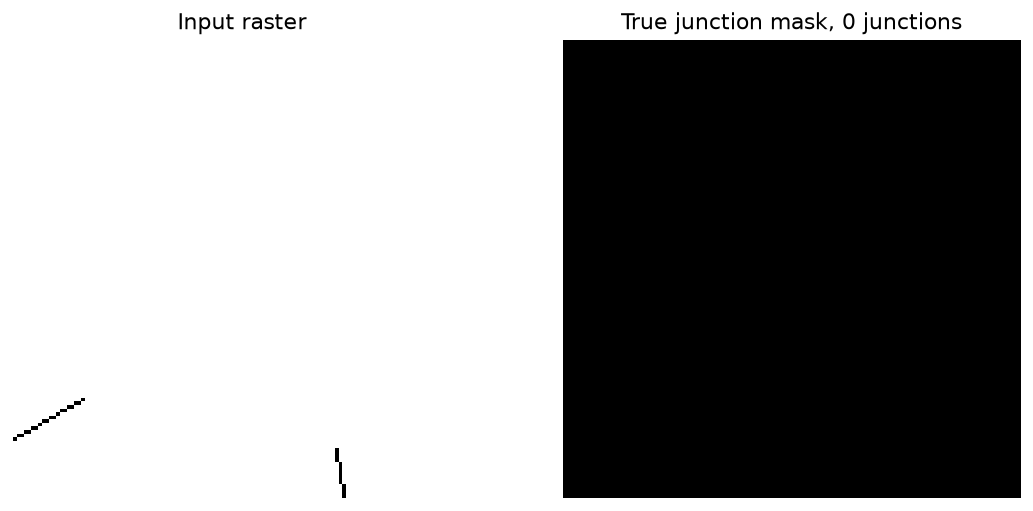

In [3]:
def segment_intersection(a, b, eps=1e-9):
    x1, y1, x2, y2 = map(float, a)
    x3, y3, x4, y4 = map(float, b)
    den = (x1 - x2) * (y3 - y4) - (y1 - y2) * (x3 - x4)
    if abs(den) < eps:
        return None
    px = ((x1*y2 - y1*x2) * (x3 - x4) - (x1 - x2) * (x3*y4 - y3*x4)) / den
    py = ((x1*y2 - y1*x2) * (y3 - y4) - (y1 - y2) * (x3*y4 - y3*x4)) / den

    def between(p, q, r):
        return min(p, r) - 1e-6 <= q <= max(p, r) + 1e-6

    if between(x1, px, x2) and between(y1, py, y2) and between(x3, px, x4) and between(y3, py, y4):
        return px, py
    return None


def junction_mask_from_vectors(vectors, img_size=IMG_SIZE, radius=JUNCTION_RADIUS):
    mask = np.zeros((img_size, img_size), dtype=np.float32)
    points = []
    for i in range(len(vectors)):
        for j in range(i + 1, len(vectors)):
            p = segment_intersection(vectors[i], vectors[j])
            if p is not None:
                points.append(p)
                cx, cy = p
                for y in range(max(0, int(cy - radius)), min(img_size, int(cy + radius) + 1)):
                    for x in range(max(0, int(cx - radius)), min(img_size, int(cx + radius) + 1)):
                        if (x - cx) ** 2 + (y - cy) ** 2 <= radius ** 2:
                            mask[y, x] = 1.0
    return mask, points

train_junction_masks = []
for vecs in train_vectors:
    m, _ = junction_mask_from_vectors(vecs)
    train_junction_masks.append(m)
train_junction_masks = np.stack(train_junction_masks)

sample_idx = 0
jm, pts = junction_mask_from_vectors(train_vectors[sample_idx])
fig, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=130)
ax[0].imshow(train_images[sample_idx], cmap='gray', vmin=0, vmax=1, interpolation='nearest')
ax[0].set_title('Input raster')
ax[1].imshow(jm, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
ax[1].set_title(f'True junction mask, {len(pts)} junctions')
for a in ax:
    a.axis('off')
plt.show()

## 3. Patch dataset for junction classification

Each training item is a small local patch around a pixel. The label is whether the centre pixel is part of a true junction region.

To avoid a huge class imbalance, the dataset samples:

- positive patches from true junction pixels,
- hard negatives from normal stroke pixels,
- background negatives.

In [4]:
def threshold_stroke(image):
    return (image <= 0.5).astype(np.uint8)


def extract_patch(mask, x, y, patch_size=PATCH_SIZE):
    r = patch_size // 2
    padded = np.pad(mask.astype(np.float32), r, mode='constant', constant_values=0)
    yp = y + r
    xp = x + r
    return padded[yp-r:yp+r+1, xp-r:xp+r+1]


def build_patch_dataset(images, junction_masks, max_pos_per_image=80, max_neg_stroke_per_image=80, max_neg_bg_per_image=80):
    X, y = [], []
    for img, jm in zip(images, junction_masks):
        stroke = threshold_stroke(img)
        pos = np.argwhere(jm > 0.5)
        stroke_neg = np.argwhere((stroke == 1) & (jm <= 0.5))
        bg_neg = np.argwhere((stroke == 0) & (jm <= 0.5))

        def sample_rows(arr, n):
            if len(arr) == 0:
                return []
            ids = np.random.choice(len(arr), size=min(n, len(arr)), replace=False)
            return arr[ids]

        for yy, xx in sample_rows(pos, max_pos_per_image):
            X.append(extract_patch(stroke, xx, yy))
            y.append(1.0)
        for yy, xx in sample_rows(stroke_neg, max_neg_stroke_per_image):
            X.append(extract_patch(stroke, xx, yy))
            y.append(0.0)
        for yy, xx in sample_rows(bg_neg, max_neg_bg_per_image):
            X.append(extract_patch(stroke, xx, yy))
            y.append(0.0)

    X = np.stack(X).astype(np.float32)
    y = np.array(y, dtype=np.float32)
    return X, y

X_patch, y_patch = build_patch_dataset(train_images, train_junction_masks)
print('Patch dataset:', X_patch.shape, y_patch.shape)
print('Positive rate:', y_patch.mean())

# Shuffle once.
perm = np.random.permutation(len(X_patch))
X_patch = X_patch[perm]
y_patch = y_patch[perm]

split = int(len(X_patch) * 0.85)
X_train_patch, X_val_patch = X_patch[:split], X_patch[split:]
y_train_patch, y_val_patch = y_patch[:split], y_patch[split:]

Patch dataset: (93035, 9, 9) (93035,)
Positive rate: 0.028623637


## 4. MLP and small CNN junction classifiers

The MLP sees a flattened 9×9 patch. The CNN sees the 9×9 patch as a small image.

In [5]:
class JunctionMLP(nn.Module):
    def __init__(self, patch_size=PATCH_SIZE):
        super().__init__()
        n = patch_size * patch_size
        self.net = nn.Sequential(
            nn.Linear(n, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x).squeeze(1)


class JunctionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 12, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(12, 24, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(24 * PATCH_SIZE * PATCH_SIZE, 48)
        self.fc2 = nn.Linear(48, 1)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x).squeeze(1)


def make_loader(X, y, batch_size=BATCH_SIZE, shuffle=True, cnn=False):
    X_t = torch.tensor(X, dtype=torch.float32)
    if cnn:
        X_t = X_t[:, None, :, :]
    y_t = torch.tensor(y, dtype=torch.float32)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)


def train_binary_model(model, train_loader, val_loader, epochs, lr=LEARNING_RATE):
    model = model.to(DEVICE)
    # Positive class is rare, so use pos_weight.
    pos = float(y_train_patch.sum())
    neg = float(len(y_train_patch) - y_train_patch.sum())
    pos_weight = torch.tensor([max(1.0, neg / max(pos, 1.0))], device=DEVICE)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()
            losses.append(loss.item())

        model.eval()
        val_losses = []
        tp = fp = tn = fn = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = loss_fn(logits, yb)
                val_losses.append(loss.item())
                pred = (torch.sigmoid(logits) >= 0.5).float()
                tp += int(((pred == 1) & (yb == 1)).sum().item())
                fp += int(((pred == 1) & (yb == 0)).sum().item())
                tn += int(((pred == 0) & (yb == 0)).sum().item())
                fn += int(((pred == 0) & (yb == 1)).sum().item())
        precision = tp / max(tp + fp, 1)
        recall = tp / max(tp + fn, 1)
        f1 = 2 * precision * recall / max(precision + recall, 1e-9)
        msg = f'Epoch {epoch:02d}: train_loss={np.mean(losses):.4f}, val_loss={np.mean(val_losses):.4f}, P={precision:.3f}, R={recall:.3f}, F1={f1:.3f}'
        print(msg)
        history.append((np.mean(losses), np.mean(val_losses), precision, recall, f1))
    return model, history

mlp = JunctionMLP()
cnn = JunctionCNN()

mlp_train_loader = make_loader(X_train_patch, y_train_patch, cnn=False)
mlp_val_loader = make_loader(X_val_patch, y_val_patch, shuffle=False, cnn=False)
cnn_train_loader = make_loader(X_train_patch, y_train_patch, cnn=True)
cnn_val_loader = make_loader(X_val_patch, y_val_patch, shuffle=False, cnn=True)

print('Training MLP junction classifier')
mlp, mlp_history = train_binary_model(mlp, mlp_train_loader, mlp_val_loader, MLP_EPOCHS)

print('\nTraining CNN... junction classifier')
cnn, cnn_history = train_binary_model(cnn, cnn_train_loader, cnn_val_loader, CNN_EPOCHS)

Training MLP junction classifier
Epoch 01: train_loss=0.7075, val_loss=0.1900, P=0.475, R=0.968, F1=0.637
Epoch 02: train_loss=0.1525, val_loss=0.1614, P=0.484, R=0.997, F1=0.652
Epoch 03: train_loss=0.1329, val_loss=0.1433, P=0.575, R=0.955, F1=0.718
Epoch 04: train_loss=0.1225, val_loss=0.1287, P=0.539, R=0.984, F1=0.696

Training CNN... junction classifier
Epoch 01: train_loss=0.3044, val_loss=0.1322, P=0.663, R=0.968, F1=0.787
Epoch 02: train_loss=0.1402, val_loss=0.1121, P=0.681, R=0.981, F1=0.804
Epoch 03: train_loss=0.1168, val_loss=0.1070, P=0.688, R=0.981, F1=0.809
Epoch 04: train_loss=0.1162, val_loss=0.1236, P=0.540, R=0.995, F1=0.700


## 5. Predict junction masks over a full raster

The stroke mask still comes from thresholding. The trained model only predicts where the reconstruction algorithm should treat pixels as a junction region.

In [6]:
def predict_junction_mask_mlp(image, model=mlp, threshold=0.9):
    stroke = threshold_stroke(image)
    patches = []
    coords = []
    ys, xs = np.where(stroke == 1)
    for y, x in zip(ys, xs):
        patches.append(extract_patch(stroke, x, y))
        coords.append((y, x))
    out = np.zeros_like(stroke, dtype=np.uint8)
    if not patches:
        return out
    X = torch.tensor(np.stack(patches).astype(np.float32), device=DEVICE)
    model.eval()
    probs = []
    with torch.no_grad():
        for i in range(0, len(X), 4096):
            p = torch.sigmoid(model(X[i:i+4096])).detach().cpu().numpy()
            probs.append(p)
    probs = np.concatenate(probs)
    for (y, x), p in zip(coords, probs):
        if p >= threshold:
            out[y, x] = 1
    return expand_mask(out, radius=1)


def predict_junction_mask_cnn(image, model=cnn, threshold=0.9):
    stroke = threshold_stroke(image)
    patches = []
    coords = []
    ys, xs = np.where(stroke == 1)
    for y, x in zip(ys, xs):
        patches.append(extract_patch(stroke, x, y))
        coords.append((y, x))
    out = np.zeros_like(stroke, dtype=np.uint8)
    if not patches:
        return out
    X = torch.tensor(np.stack(patches).astype(np.float32)[:, None, :, :], device=DEVICE)
    model.eval()
    probs = []
    with torch.no_grad():
        for i in range(0, len(X), 4096):
            p = torch.sigmoid(model(X[i:i+4096])).detach().cpu().numpy()
            probs.append(p)
    probs = np.concatenate(probs)
    for (y, x), p in zip(coords, probs):
        if p >= threshold:
            out[y, x] = 1
    return expand_mask(out, radius=1)


def neighbour_count(mask, y, x):
    h, w = mask.shape
    c = 0
    for dy in (-1, 0, 1):
        for dx in (-1, 0, 1):
            if dx == 0 and dy == 0:
                continue
            yy, xx = y + dy, x + dx
            if 0 <= yy < h and 0 <= xx < w and mask[yy, xx]:
                c += 1
    return c


def baseline_graph_junction_mask(image):
    stroke = threshold_stroke(image)
    out = np.zeros_like(stroke, dtype=np.uint8)
    ys, xs = np.where(stroke == 1)
    for y, x in zip(ys, xs):
        if neighbour_count(stroke, y, x) >= 3:
            out[y, x] = 1
    return expand_mask(out, radius=1)


def expand_mask(mask, radius=1):
    out = mask.copy().astype(np.uint8)
    ys, xs = np.where(mask > 0)
    h, w = mask.shape
    for y, x in zip(ys, xs):
        for yy in range(max(0, y - radius), min(h, y + radius + 1)):
            for xx in range(max(0, x - radius), min(w, x + radius + 1)):
                if (yy - y) ** 2 + (xx - x) ** 2 <= radius ** 2:
                    out[yy, xx] = 1
    return out

## 6. Junction-aware vector reconstruction

This is the key change. Instead of creating many tiny line pieces inside a junction cluster, the algorithm contracts each predicted junction region to a single node and traces arms out from it.

This gives a middle ground:

- it does not delete the junction, so gaps are reduced;
- it does not fit many tiny lines inside the junction, so visual clutter is reduced.

In [7]:
NEIGHBOURS_8 = [
    (-1, -1), (0, -1), (1, -1),
    (-1,  0),          (1,  0),
    (-1,  1), (0,  1), (1,  1),
]


def connected_components(mask):
    mask = mask.astype(bool)
    h, w = mask.shape
    seen = np.zeros_like(mask, dtype=bool)
    comps = []
    for y in range(h):
        for x in range(w):
            if not mask[y, x] or seen[y, x]:
                continue
            q = deque([(y, x)])
            seen[y, x] = True
            comp = []
            while q:
                cy, cx = q.popleft()
                comp.append((cy, cx))
                for dx, dy in NEIGHBOURS_8:
                    ny, nx = cy + dy, cx + dx
                    if 0 <= ny < h and 0 <= nx < w and mask[ny, nx] and not seen[ny, nx]:
                        seen[ny, nx] = True
                        q.append((ny, nx))
            comps.append(comp)
    return comps


def make_node_map(stroke, junction_mask):
    h, w = stroke.shape
    node_map = -np.ones((h, w), dtype=np.int32)
    nodes = []

    # Junction nodes from connected predicted junction regions.
    for comp in connected_components(junction_mask & stroke):
        if len(comp) == 0:
            continue
        ys = np.array([p[0] for p in comp], dtype=np.float32)
        xs = np.array([p[1] for p in comp], dtype=np.float32)
        node_id = len(nodes)
        nodes.append({'type': 'junction', 'x': float(xs.mean()), 'y': float(ys.mean()), 'pixels': comp})
        for y, x in comp:
            node_map[y, x] = node_id

    # Endpoint nodes: stroke pixels with exactly one neighbour and not already in a junction.
    ys, xs = np.where(stroke == 1)
    for y, x in zip(ys, xs):
        if node_map[y, x] >= 0:
            continue
        if neighbour_count(stroke, y, x) <= 1:
            node_id = len(nodes)
            nodes.append({'type': 'endpoint', 'x': float(x), 'y': float(y), 'pixels': [(y, x)]})
            node_map[y, x] = node_id
    return nodes, node_map


def distance_point_to_line(px, py, ax, ay, bx, by):
    vx, vy = bx - ax, by - ay
    wx, wy = px - ax, py - ay
    denom = vx * vx + vy * vy
    if denom == 0:
        return math.hypot(px - ax, py - ay)
    t = max(0.0, min(1.0, (wx * vx + wy * vy) / denom))
    qx, qy = ax + t * vx, ay + t * vy
    return math.hypot(px - qx, py - qy)


def fit_line_to_path(path_points):
    if len(path_points) < 2:
        return None
    pts = np.array([(x, y) for y, x in path_points], dtype=np.float32)
    cx, cy = pts.mean(axis=0)
    centered = pts - np.array([cx, cy])
    _, _, vh = np.linalg.svd(centered, full_matrices=False)
    direction = vh[0]
    t = centered @ direction
    p0 = np.array([cx, cy]) + direction * t.min()
    p1 = np.array([cx, cy]) + direction * t.max()
    return (float(p0[0]), float(p0[1]), float(p1[0]), float(p1[1]))


def line_length(line):
    x0, y0, x1, y1 = line
    return math.hypot(x1 - x0, y1 - y0)


def trace_vectors_with_junctions(image, junction_mask):
    stroke = threshold_stroke(image)
    nodes, node_map = make_node_map(stroke, junction_mask.astype(np.uint8))
    h, w = stroke.shape
    visited_edges = set()
    vectors = []
    paths = []

    def stroke_neighbours(y, x):
        out = []
        for dx, dy in NEIGHBOURS_8:
            yy, xx = y + dy, x + dx
            if 0 <= yy < h and 0 <= xx < w and stroke[yy, xx]:
                out.append((yy, xx))
        return out

    # Start tracing from every node pixel to every adjacent non-node stroke pixel.
    for node_id, node in enumerate(nodes):
        for sy, sx in node['pixels']:
            for ny, nx in stroke_neighbours(sy, sx):
                if node_map[ny, nx] == node_id:
                    continue
                edge_key = tuple(sorted(((sy, sx), (ny, nx))))
                if edge_key in visited_edges:
                    continue

                path = [(sy, sx), (ny, nx)]
                visited_edges.add(edge_key)
                prev = (sy, sx)
                cur = (ny, nx)
                end_node = node_map[cur]
                steps = 0

                while end_node < 0 and steps < IMG_SIZE * IMG_SIZE:
                    nbrs = stroke_neighbours(*cur)
                    # avoid immediately going backwards unless there is no choice
                    candidates = [p for p in nbrs if p != prev]
                    if not candidates:
                        break
                    # Prefer moving into a node; otherwise continue along the least-branching direction.
                    node_candidates = [p for p in candidates if node_map[p] >= 0]
                    if node_candidates:
                        nxt = node_candidates[0]
                    else:
                        unvisited = []
                        for p in candidates:
                            ek = tuple(sorted((cur, p)))
                            if ek not in visited_edges:
                                unvisited.append(p)
                        if not unvisited:
                            break
                        nxt = unvisited[0]

                    ek = tuple(sorted((cur, nxt)))
                    visited_edges.add(ek)
                    prev, cur = cur, nxt
                    path.append(cur)
                    end_node = node_map[cur]
                    steps += 1

                if len(path) >= 2:
                    # Use contracted node centres at either end when present.
                    start_id = node_id
                    end_id = node_map[path[-1]]
                    raw_line = fit_line_to_path(path)
                    if raw_line is None:
                        continue
                    x0, y0, x1, y1 = raw_line
                    if start_id >= 0:
                        x0, y0 = nodes[start_id]['x'], nodes[start_id]['y']
                    if end_id >= 0:
                        x1, y1 = nodes[end_id]['x'], nodes[end_id]['y']
                    line = (x0, y0, x1, y1)
                    if line_length(line) >= MIN_VECTOR_LENGTH:
                        vectors.append(line)
                        paths.append(path)

    debug = {
        'stroke': stroke,
        'junction_mask': junction_mask,
        'nodes': nodes,
        'node_map': node_map,
        'paths': paths,
    }
    return merge_collinear_vectors_fast(vectors), debug


def angle_of(line):
    x0, y0, x1, y1 = line
    return math.atan2(y1 - y0, x1 - x0)


def angle_diff(a, b):
    d = abs(a - b) % math.pi
    return min(d, math.pi - d)


def endpoint_distance(l1, l2):
    a = [(l1[0], l1[1]), (l1[2], l1[3])]
    b = [(l2[0], l2[1]), (l2[2], l2[3])]
    return min(math.hypot(x1-x2, y1-y2) for x1,y1 in a for x2,y2 in b)


def merged_line(l1, l2):
    pts = np.array([(l1[0], l1[1]), (l1[2], l1[3]), (l2[0], l2[1]), (l2[2], l2[3])], dtype=np.float32)
    cx, cy = pts.mean(axis=0)
    centered = pts - np.array([cx, cy])
    _, _, vh = np.linalg.svd(centered, full_matrices=False)
    direction = vh[0]
    t = centered @ direction
    p0 = np.array([cx, cy]) + direction * t.min()
    p1 = np.array([cx, cy]) + direction * t.max()
    return (float(p0[0]), float(p0[1]), float(p1[0]), float(p1[1]))


def merge_collinear_vectors_fast(vectors, angle_tol_deg=8, endpoint_tol=4):
    vectors = [v for v in vectors if line_length(v) >= MIN_VECTOR_LENGTH]
    angle_tol = math.radians(angle_tol_deg)
    for _ in range(MAX_MERGE_PASSES):
        used = [False] * len(vectors)
        new_vectors = []
        changed = False
        for i, vi in enumerate(vectors):
            if used[i]:
                continue
            current = vi
            used[i] = True
            for j in range(i + 1, len(vectors)):
                if used[j]:
                    continue
                vj = vectors[j]
                if angle_diff(angle_of(current), angle_of(vj)) <= angle_tol and endpoint_distance(current, vj) <= endpoint_tol:
                    current = merged_line(current, vj)
                    used[j] = True
                    changed = True
            if line_length(current) >= MIN_VECTOR_LENGTH:
                new_vectors.append(current)
        vectors = new_vectors
        if not changed:
            break
    return vectors


def reconstruct_vectors_from_image(image, method='baseline'):
    if method == 'baseline':
        jm = baseline_graph_junction_mask(image)
    elif method == 'mlp':
        jm = predict_junction_mask_mlp(image)
    elif method == 'cnn':
        jm = predict_junction_mask_cnn(image)
    else:
        raise ValueError('method must be baseline, mlp, or cnn')
    return trace_vectors_with_junctions(image, jm)

## 7. Visual comparison

The display shows the original input and the reconstructed vectors for the baseline, MLP-junction, and CNN-junction approaches.

Random sample indices: [2, 24, 44, 43, 15, 77, 16, 72, 6, 12]
Sample 2


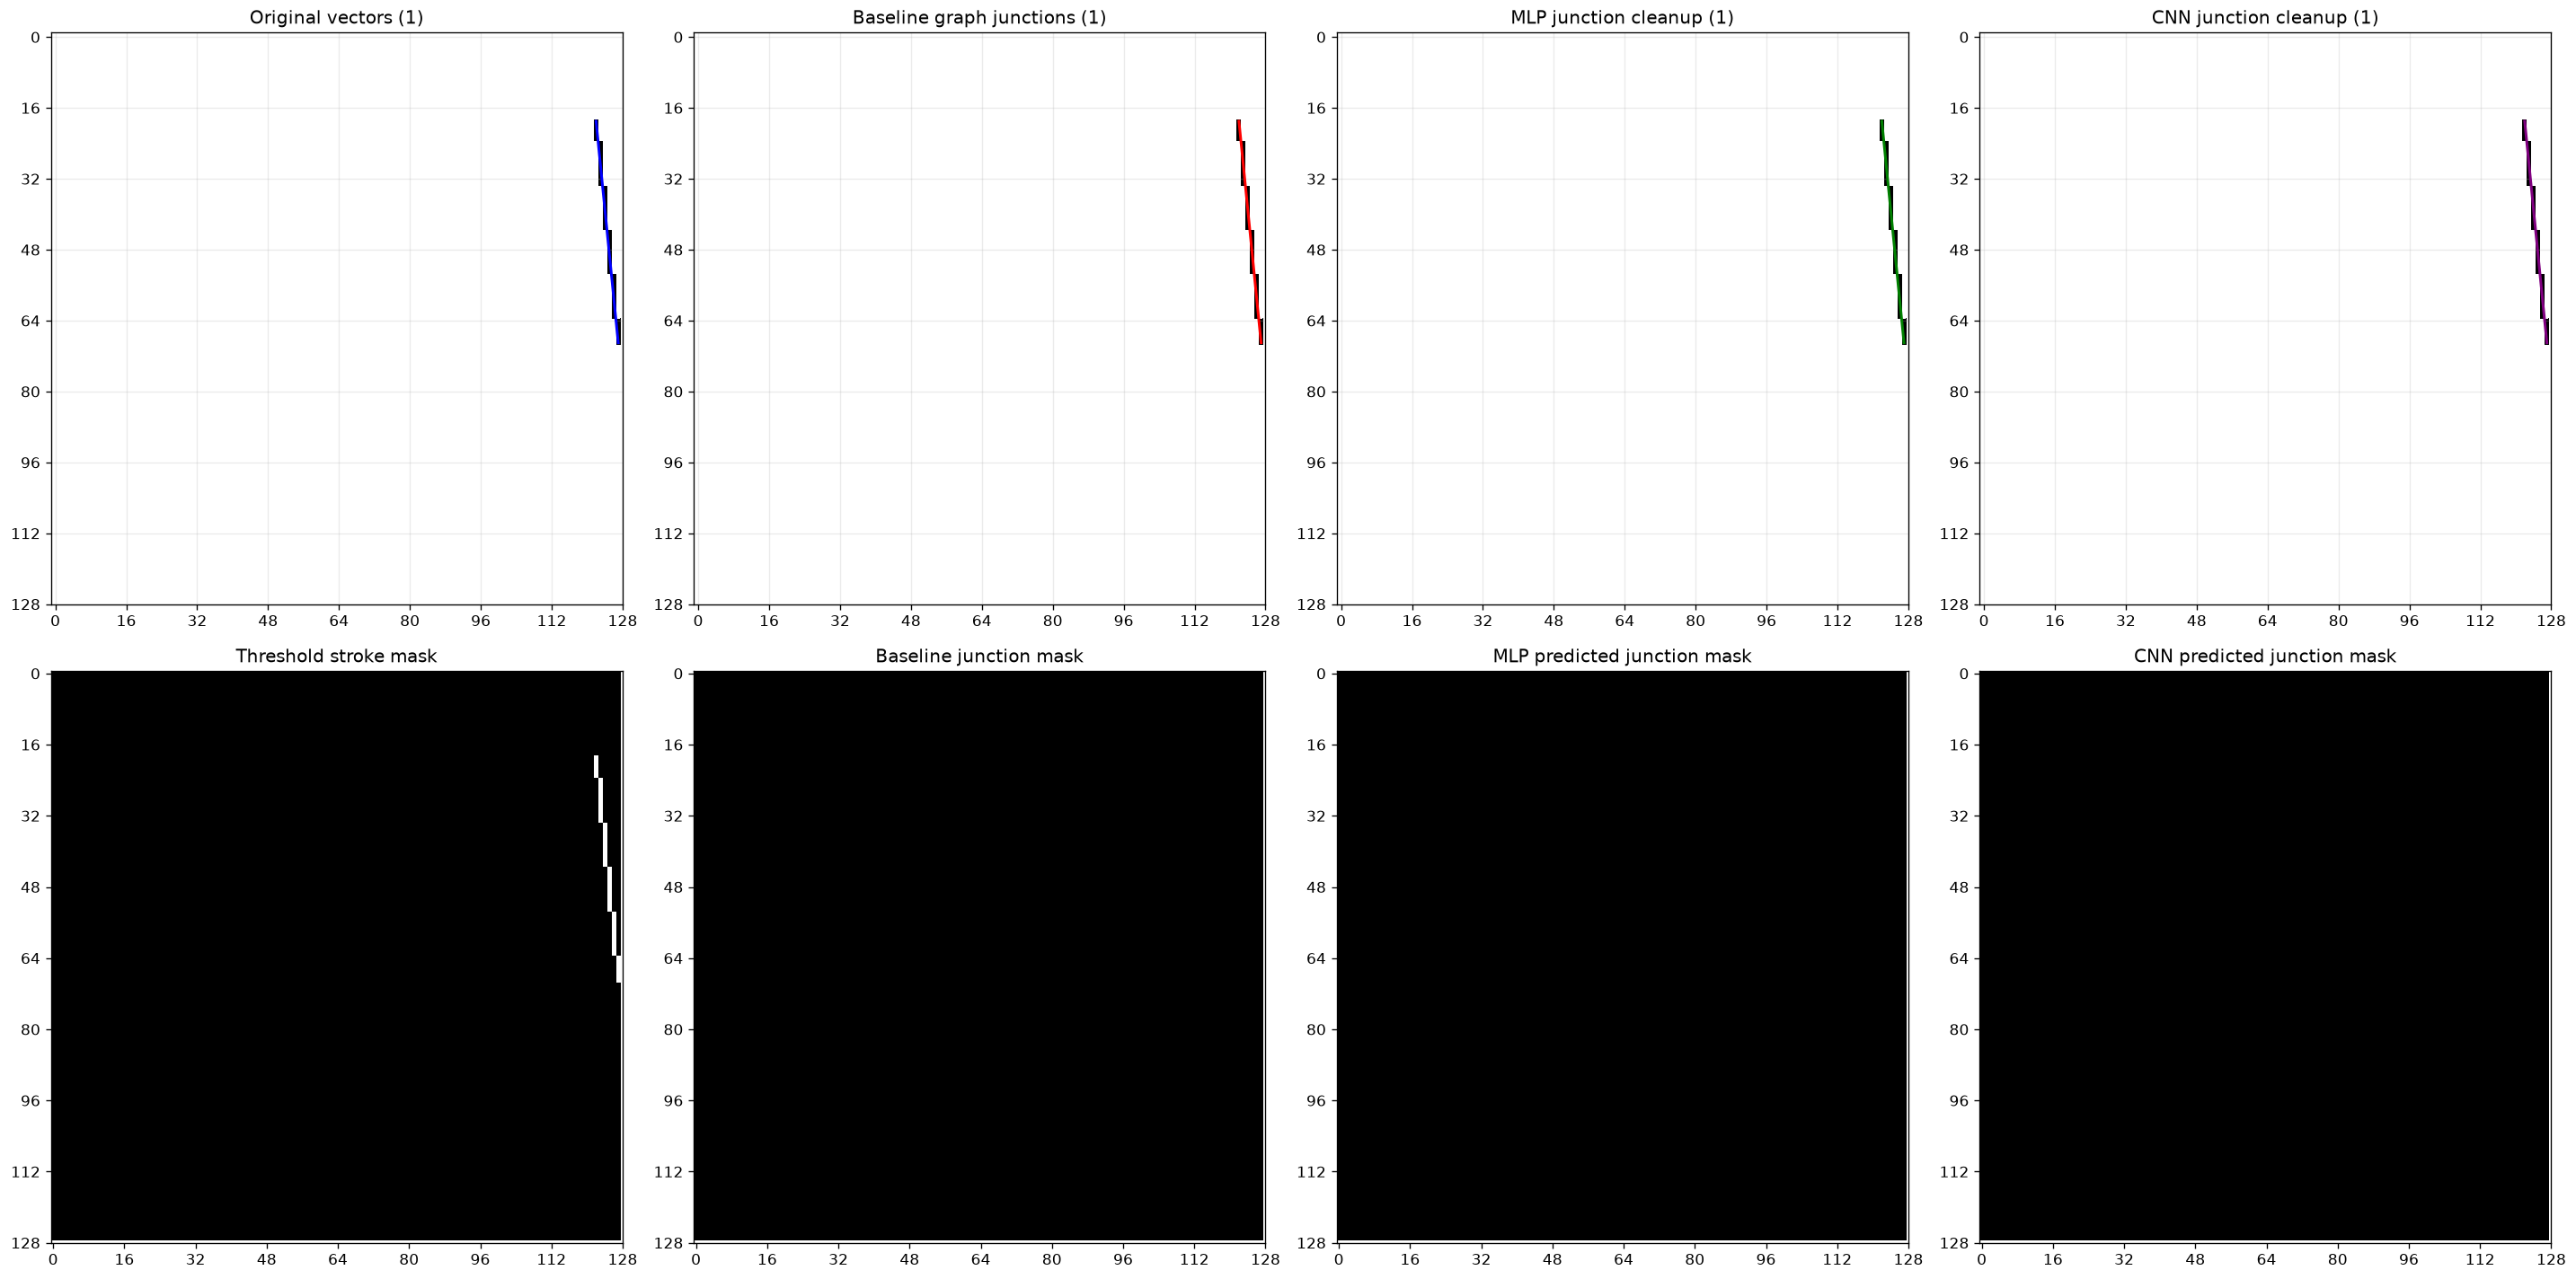

Sample 24


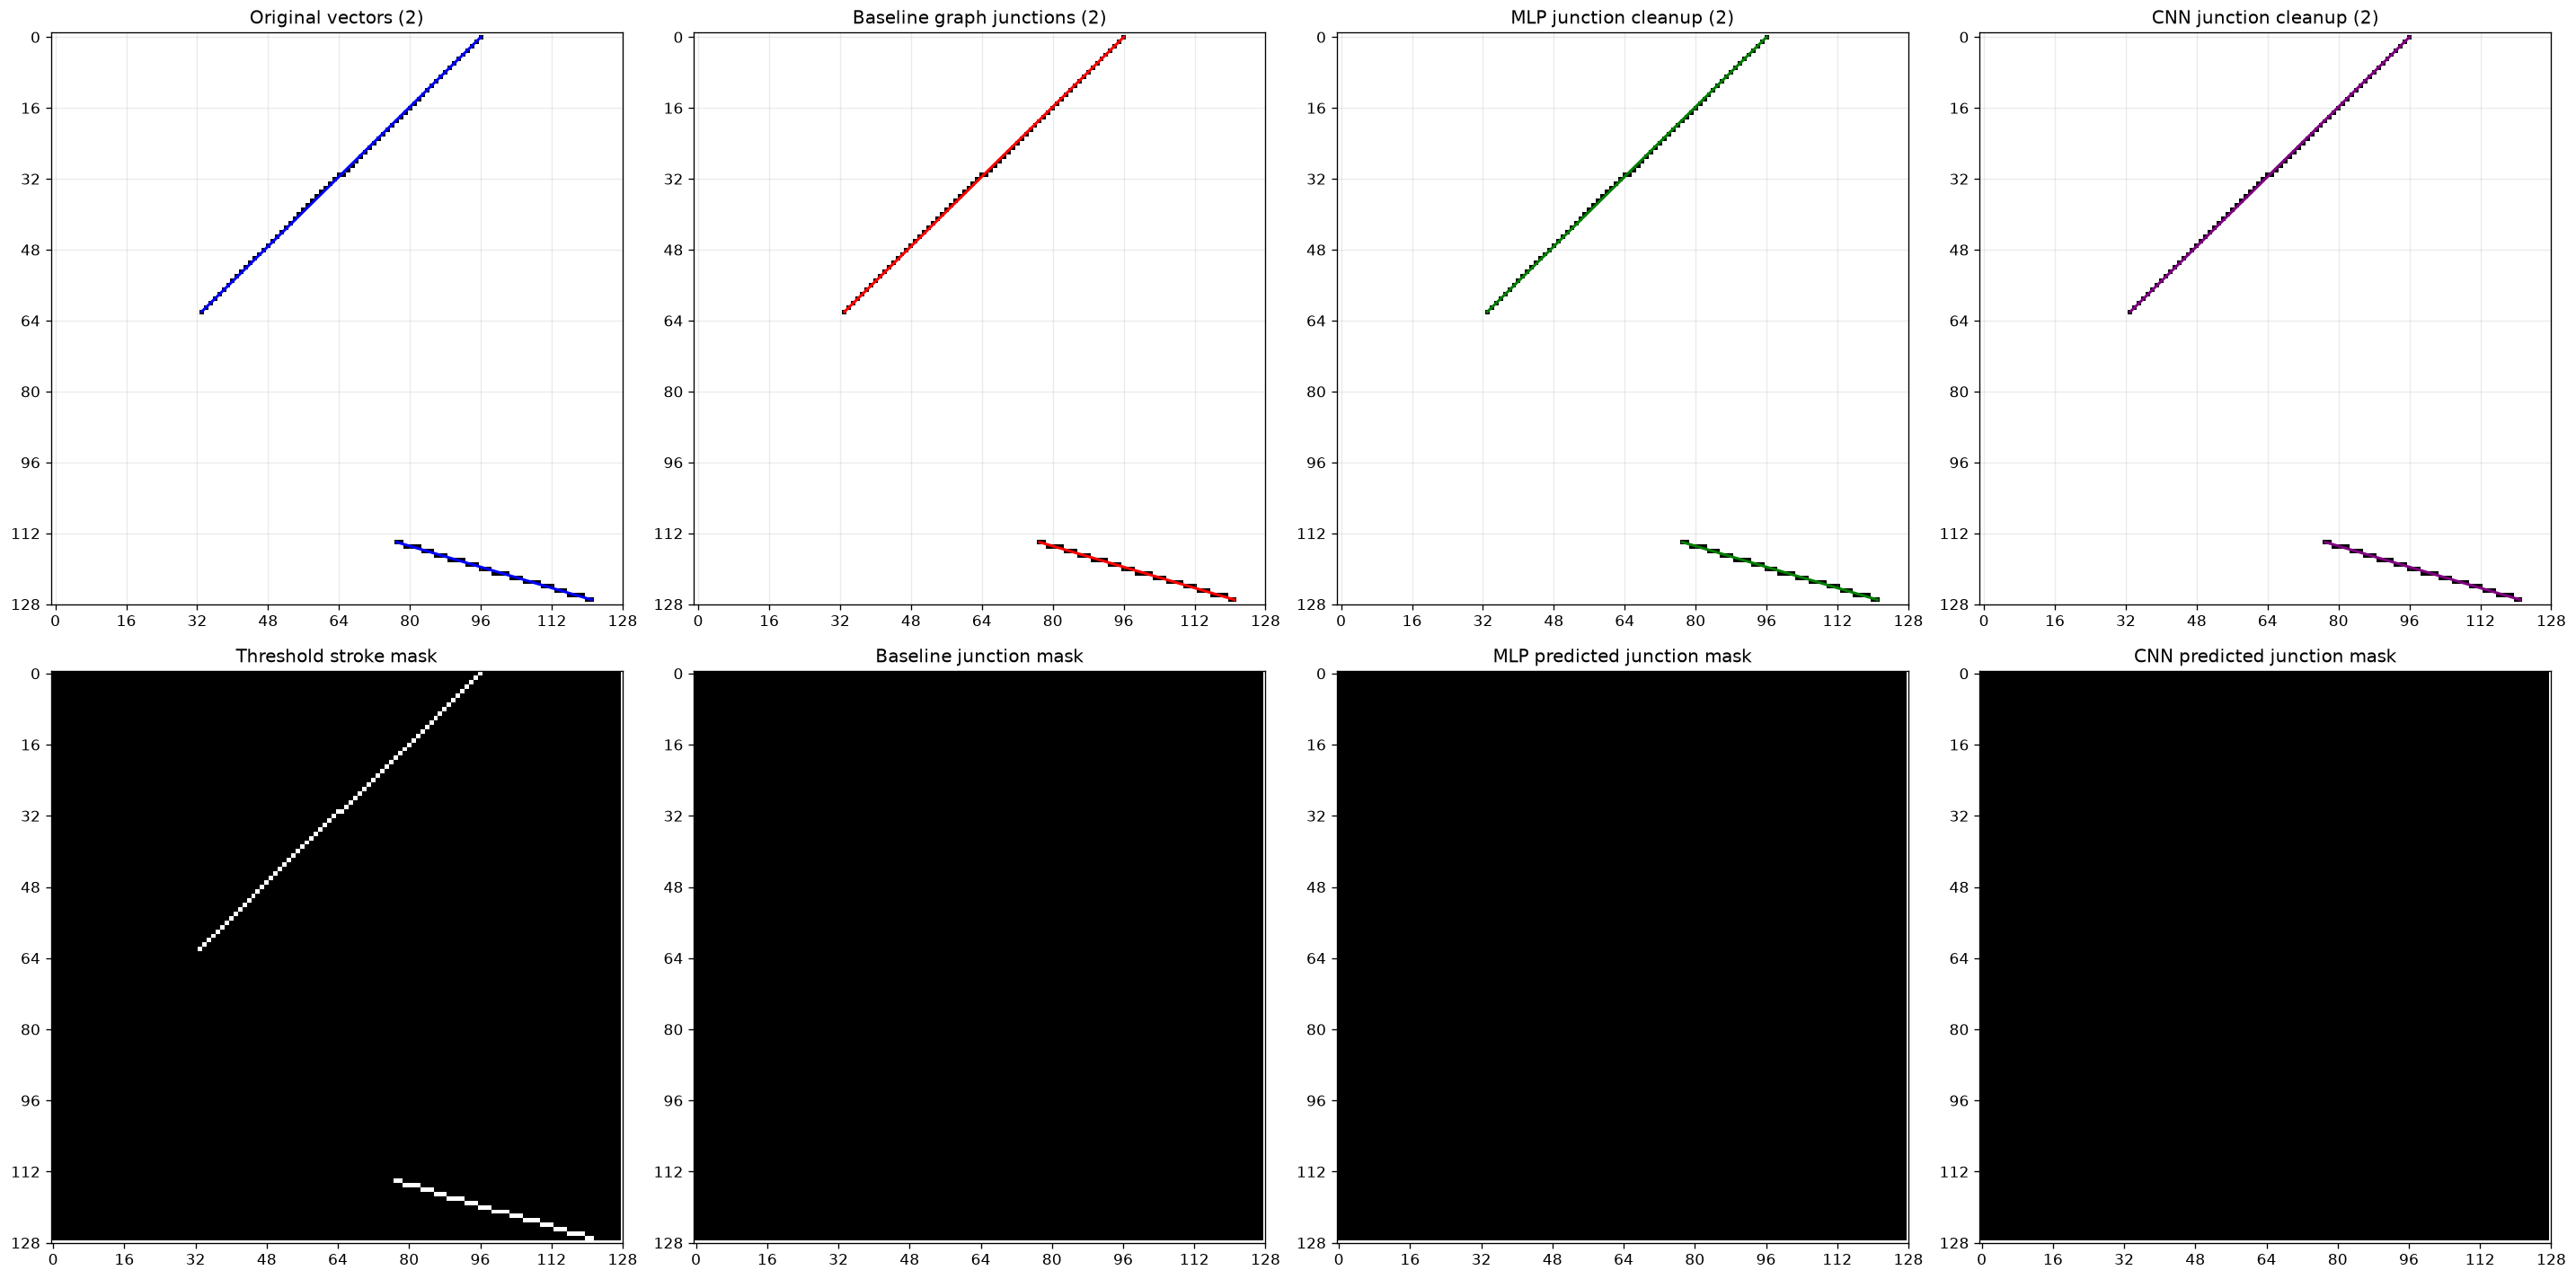

Sample 44


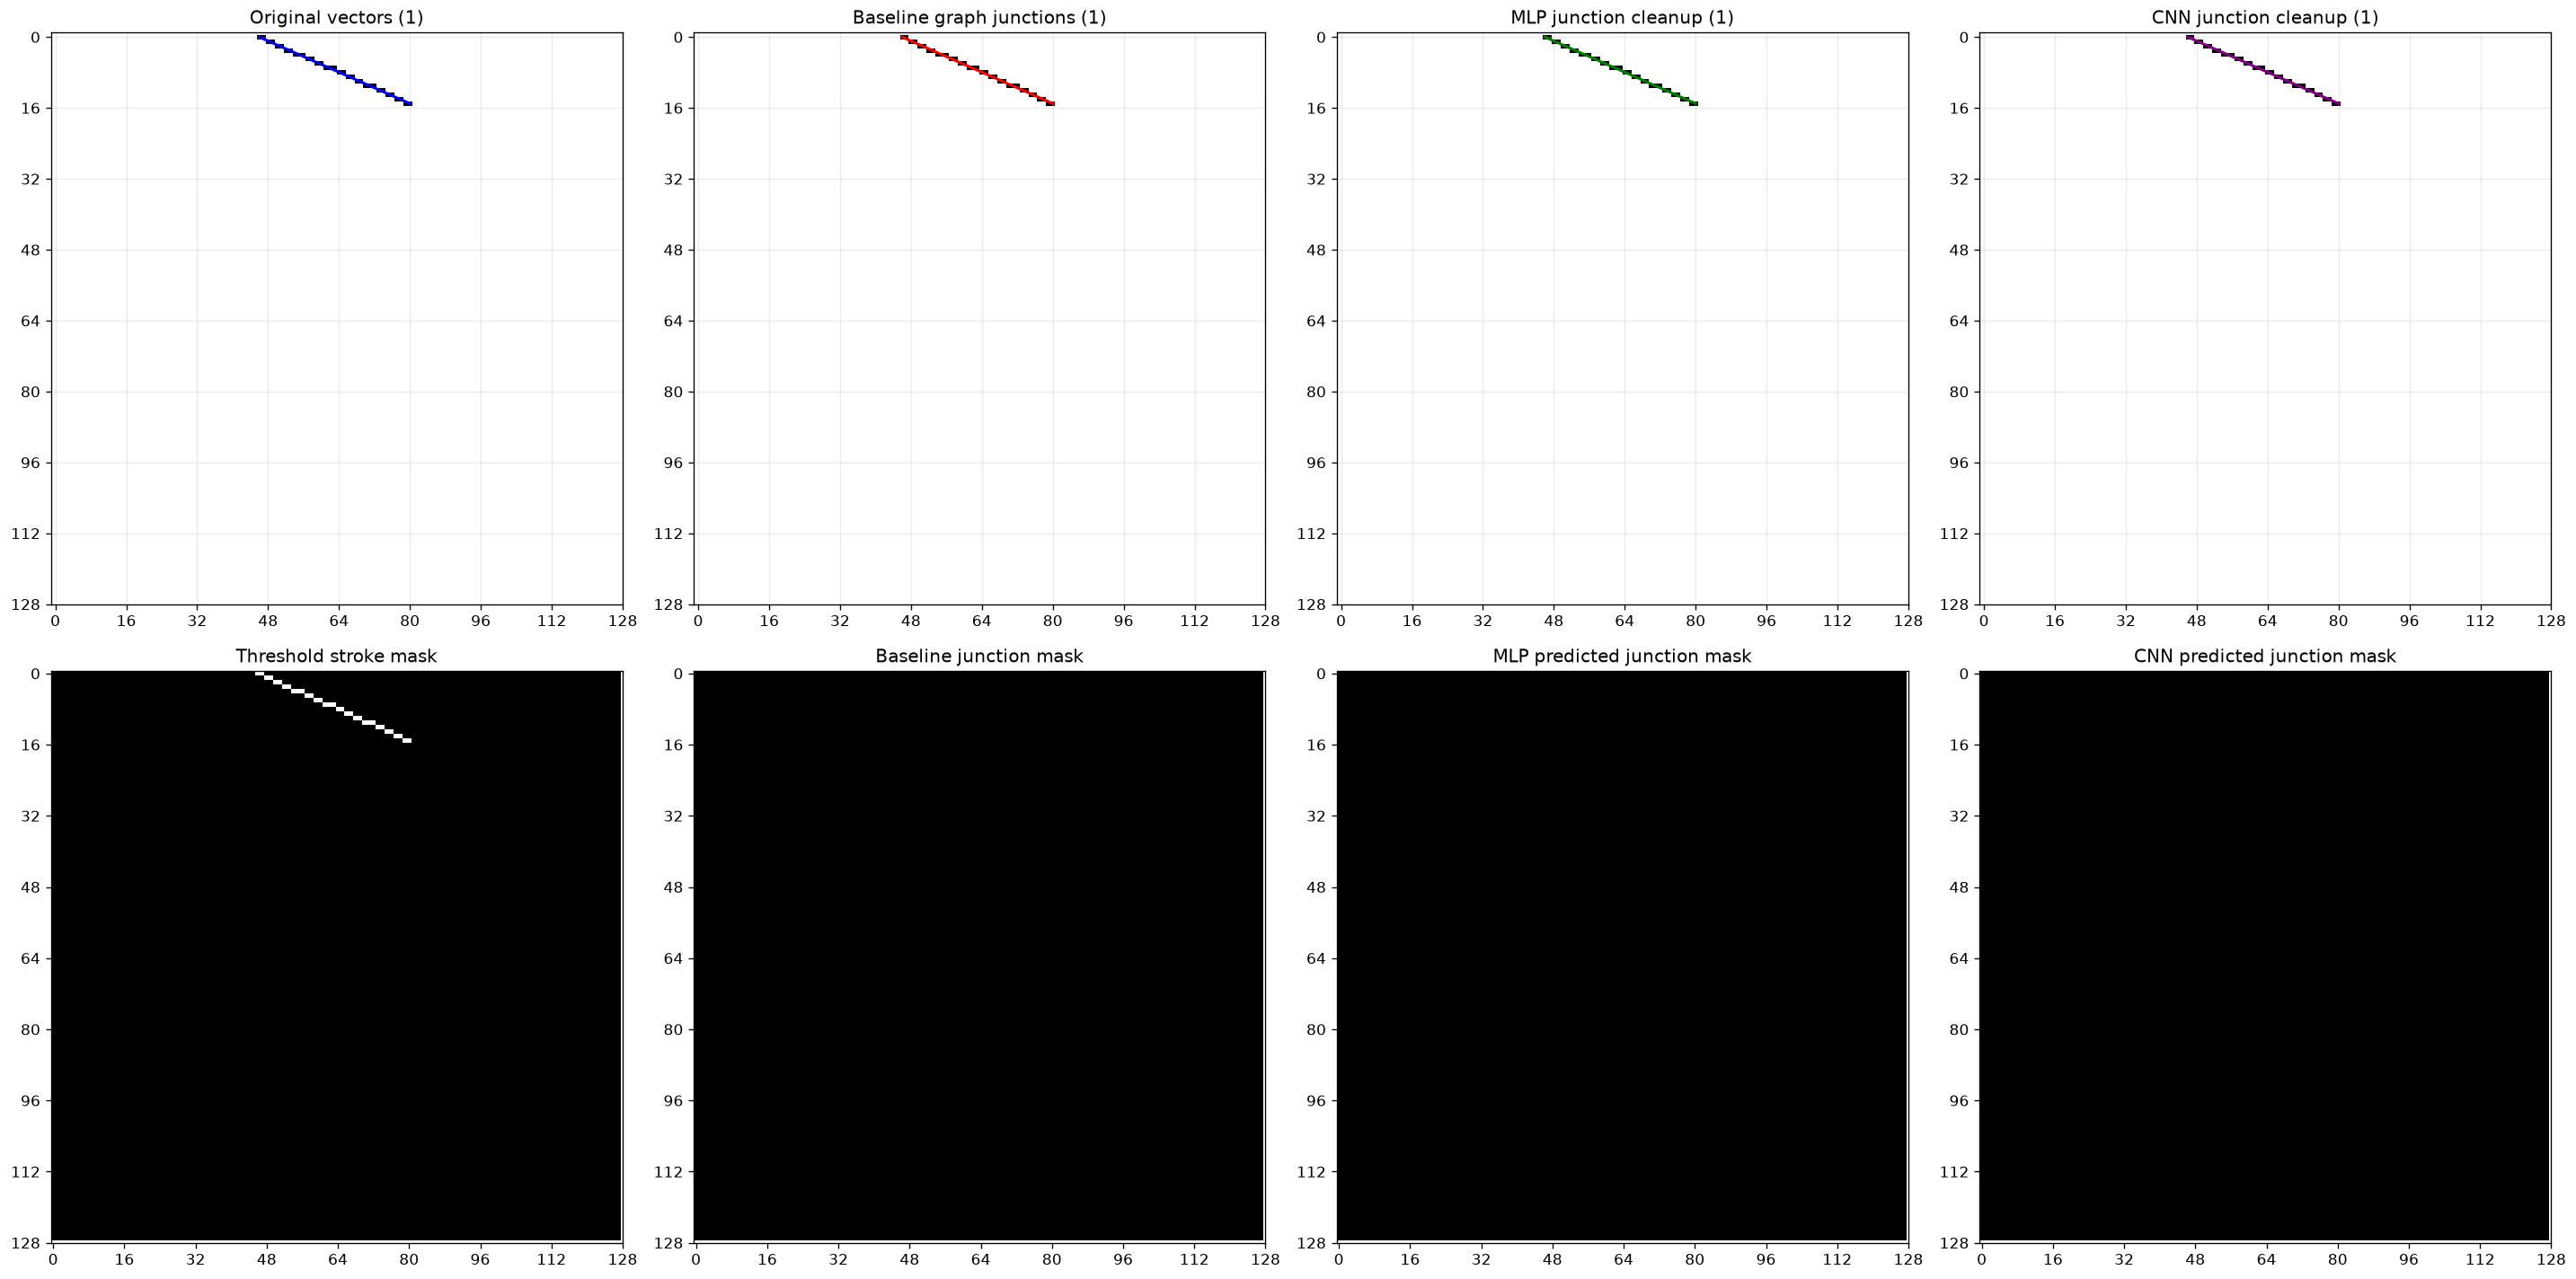

Sample 43


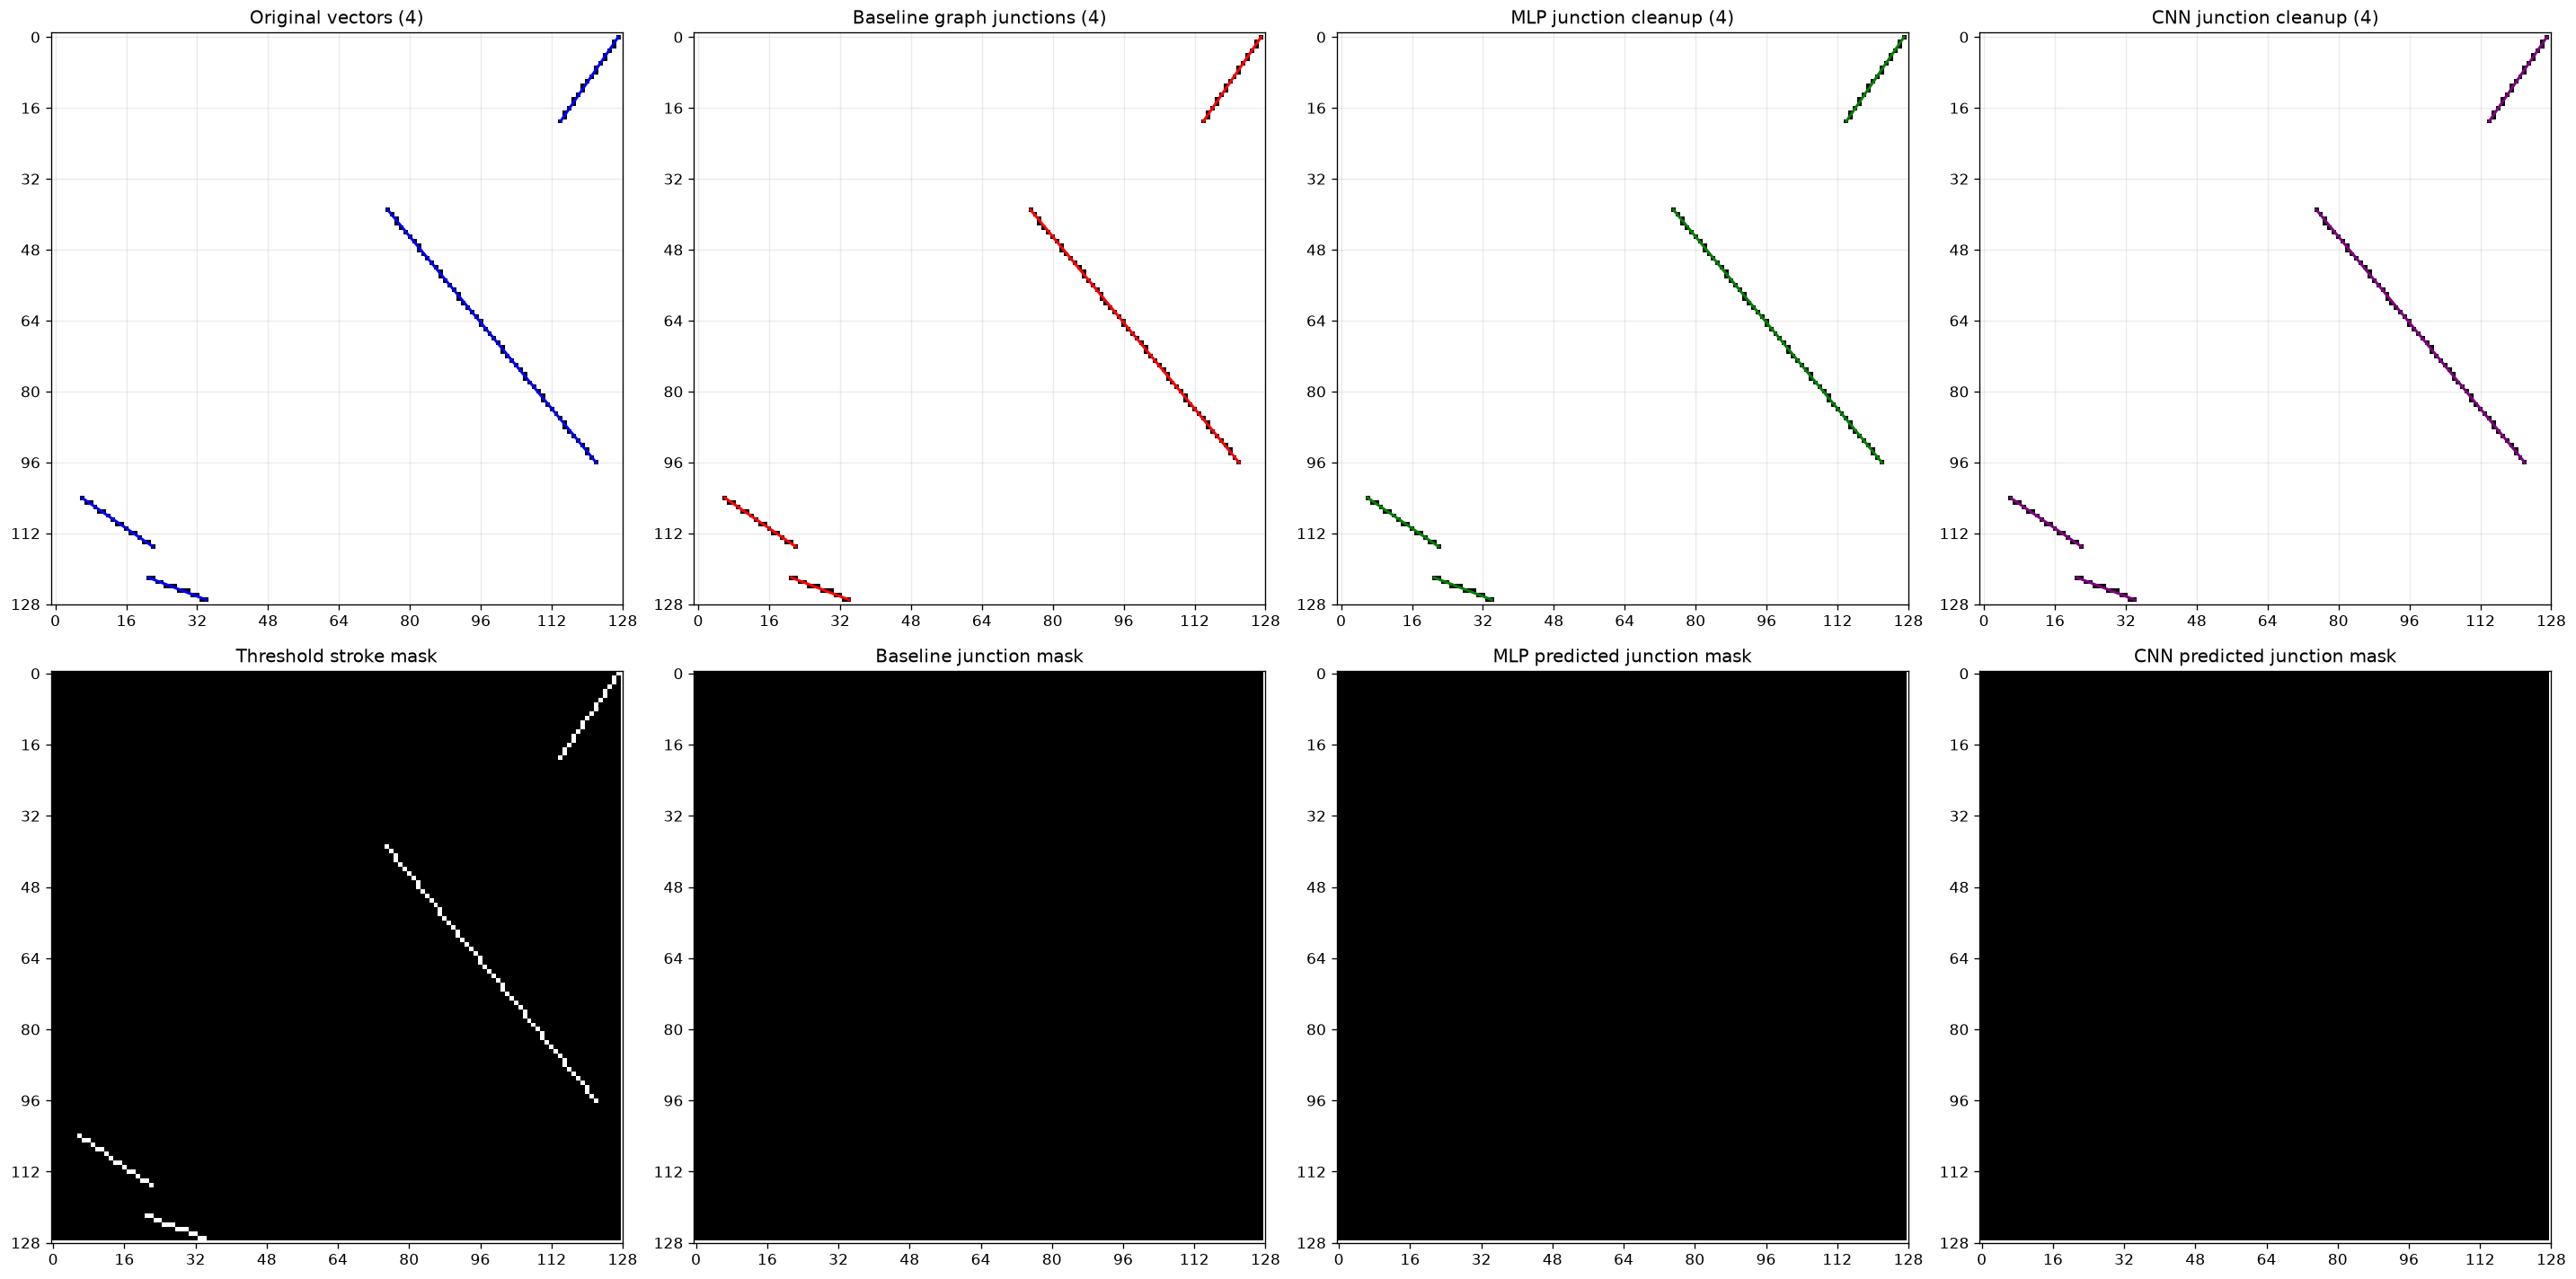

Sample 15


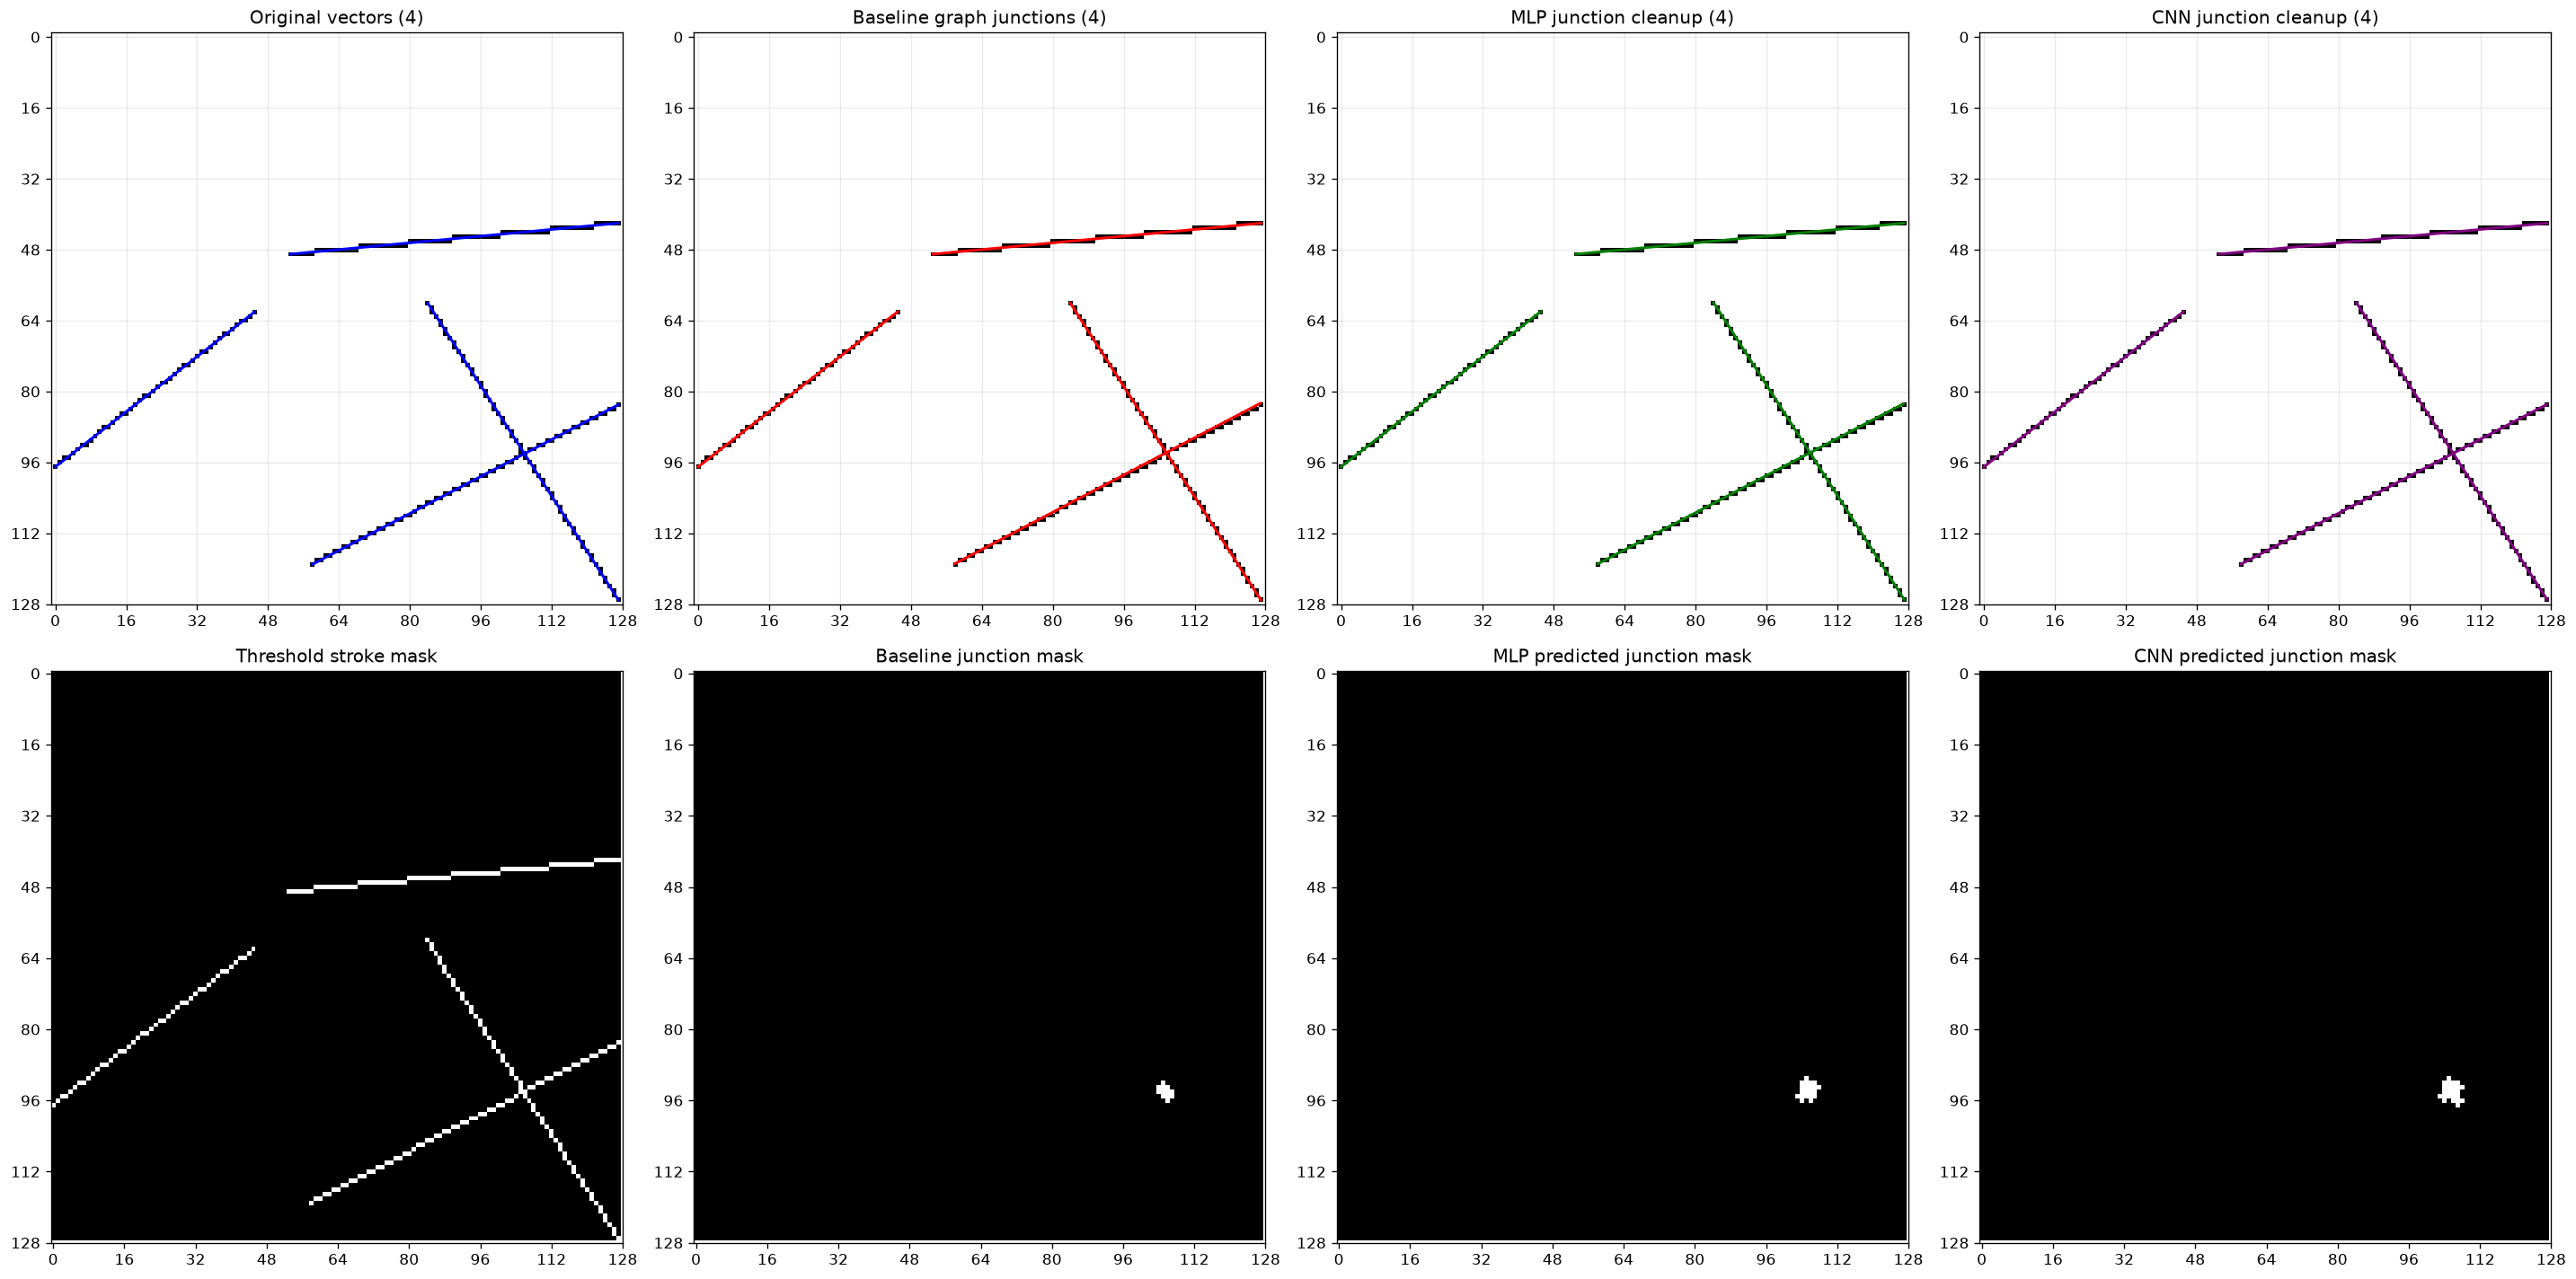

Sample 77


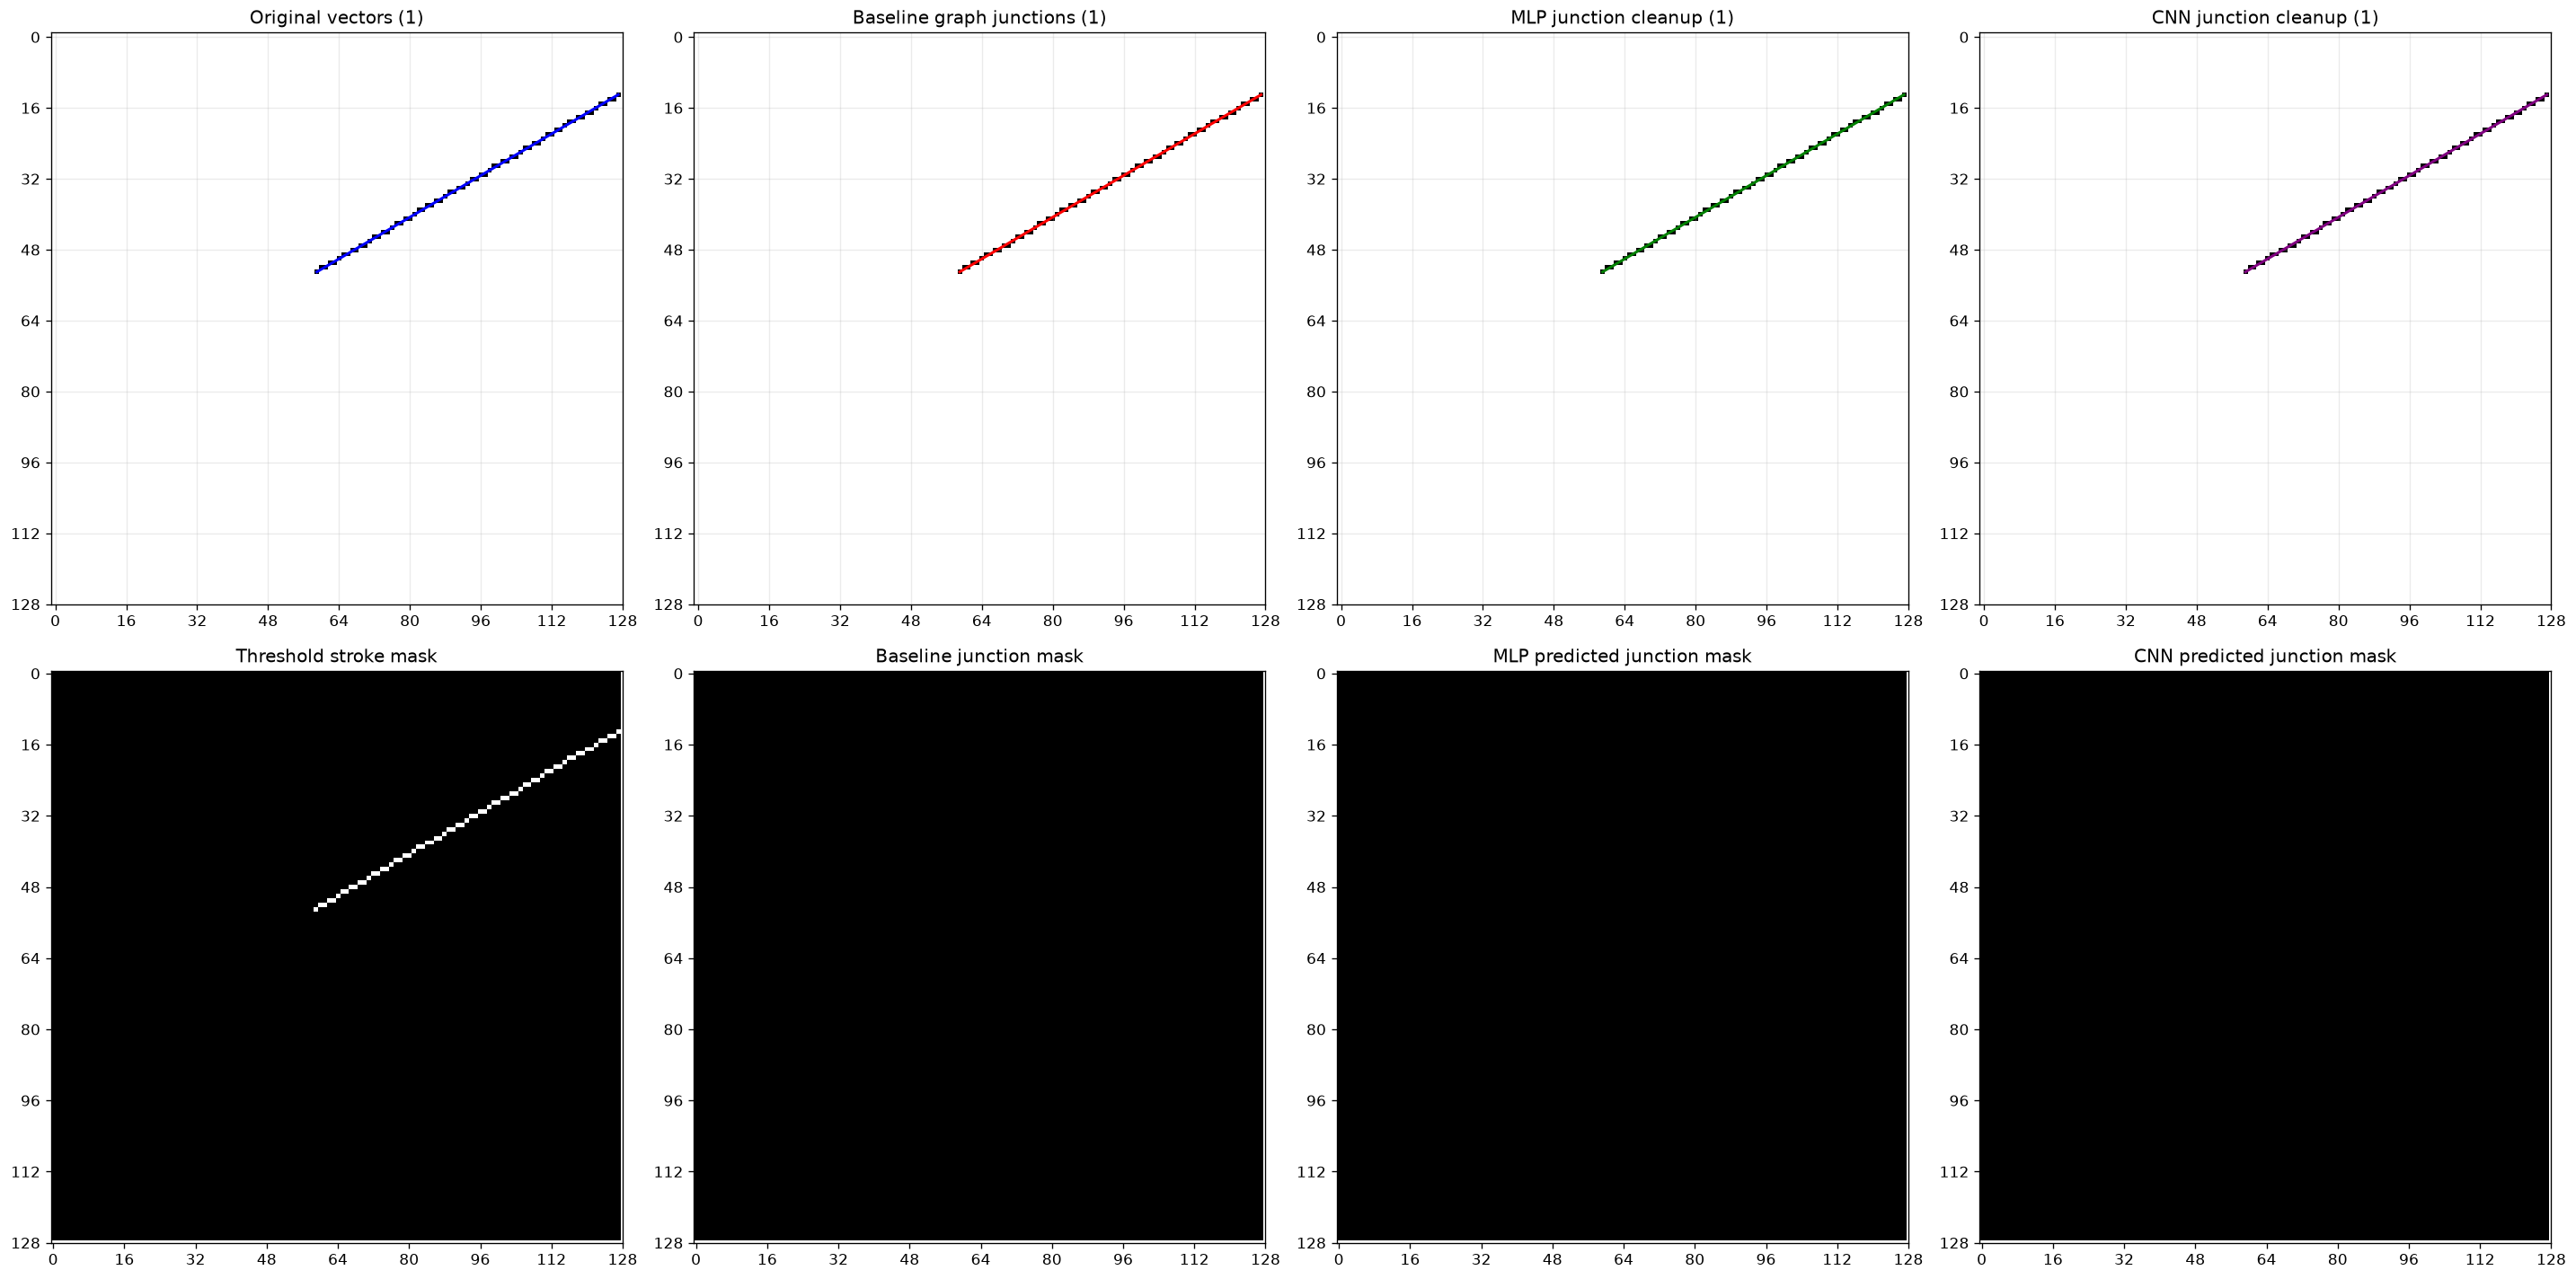

Sample 16


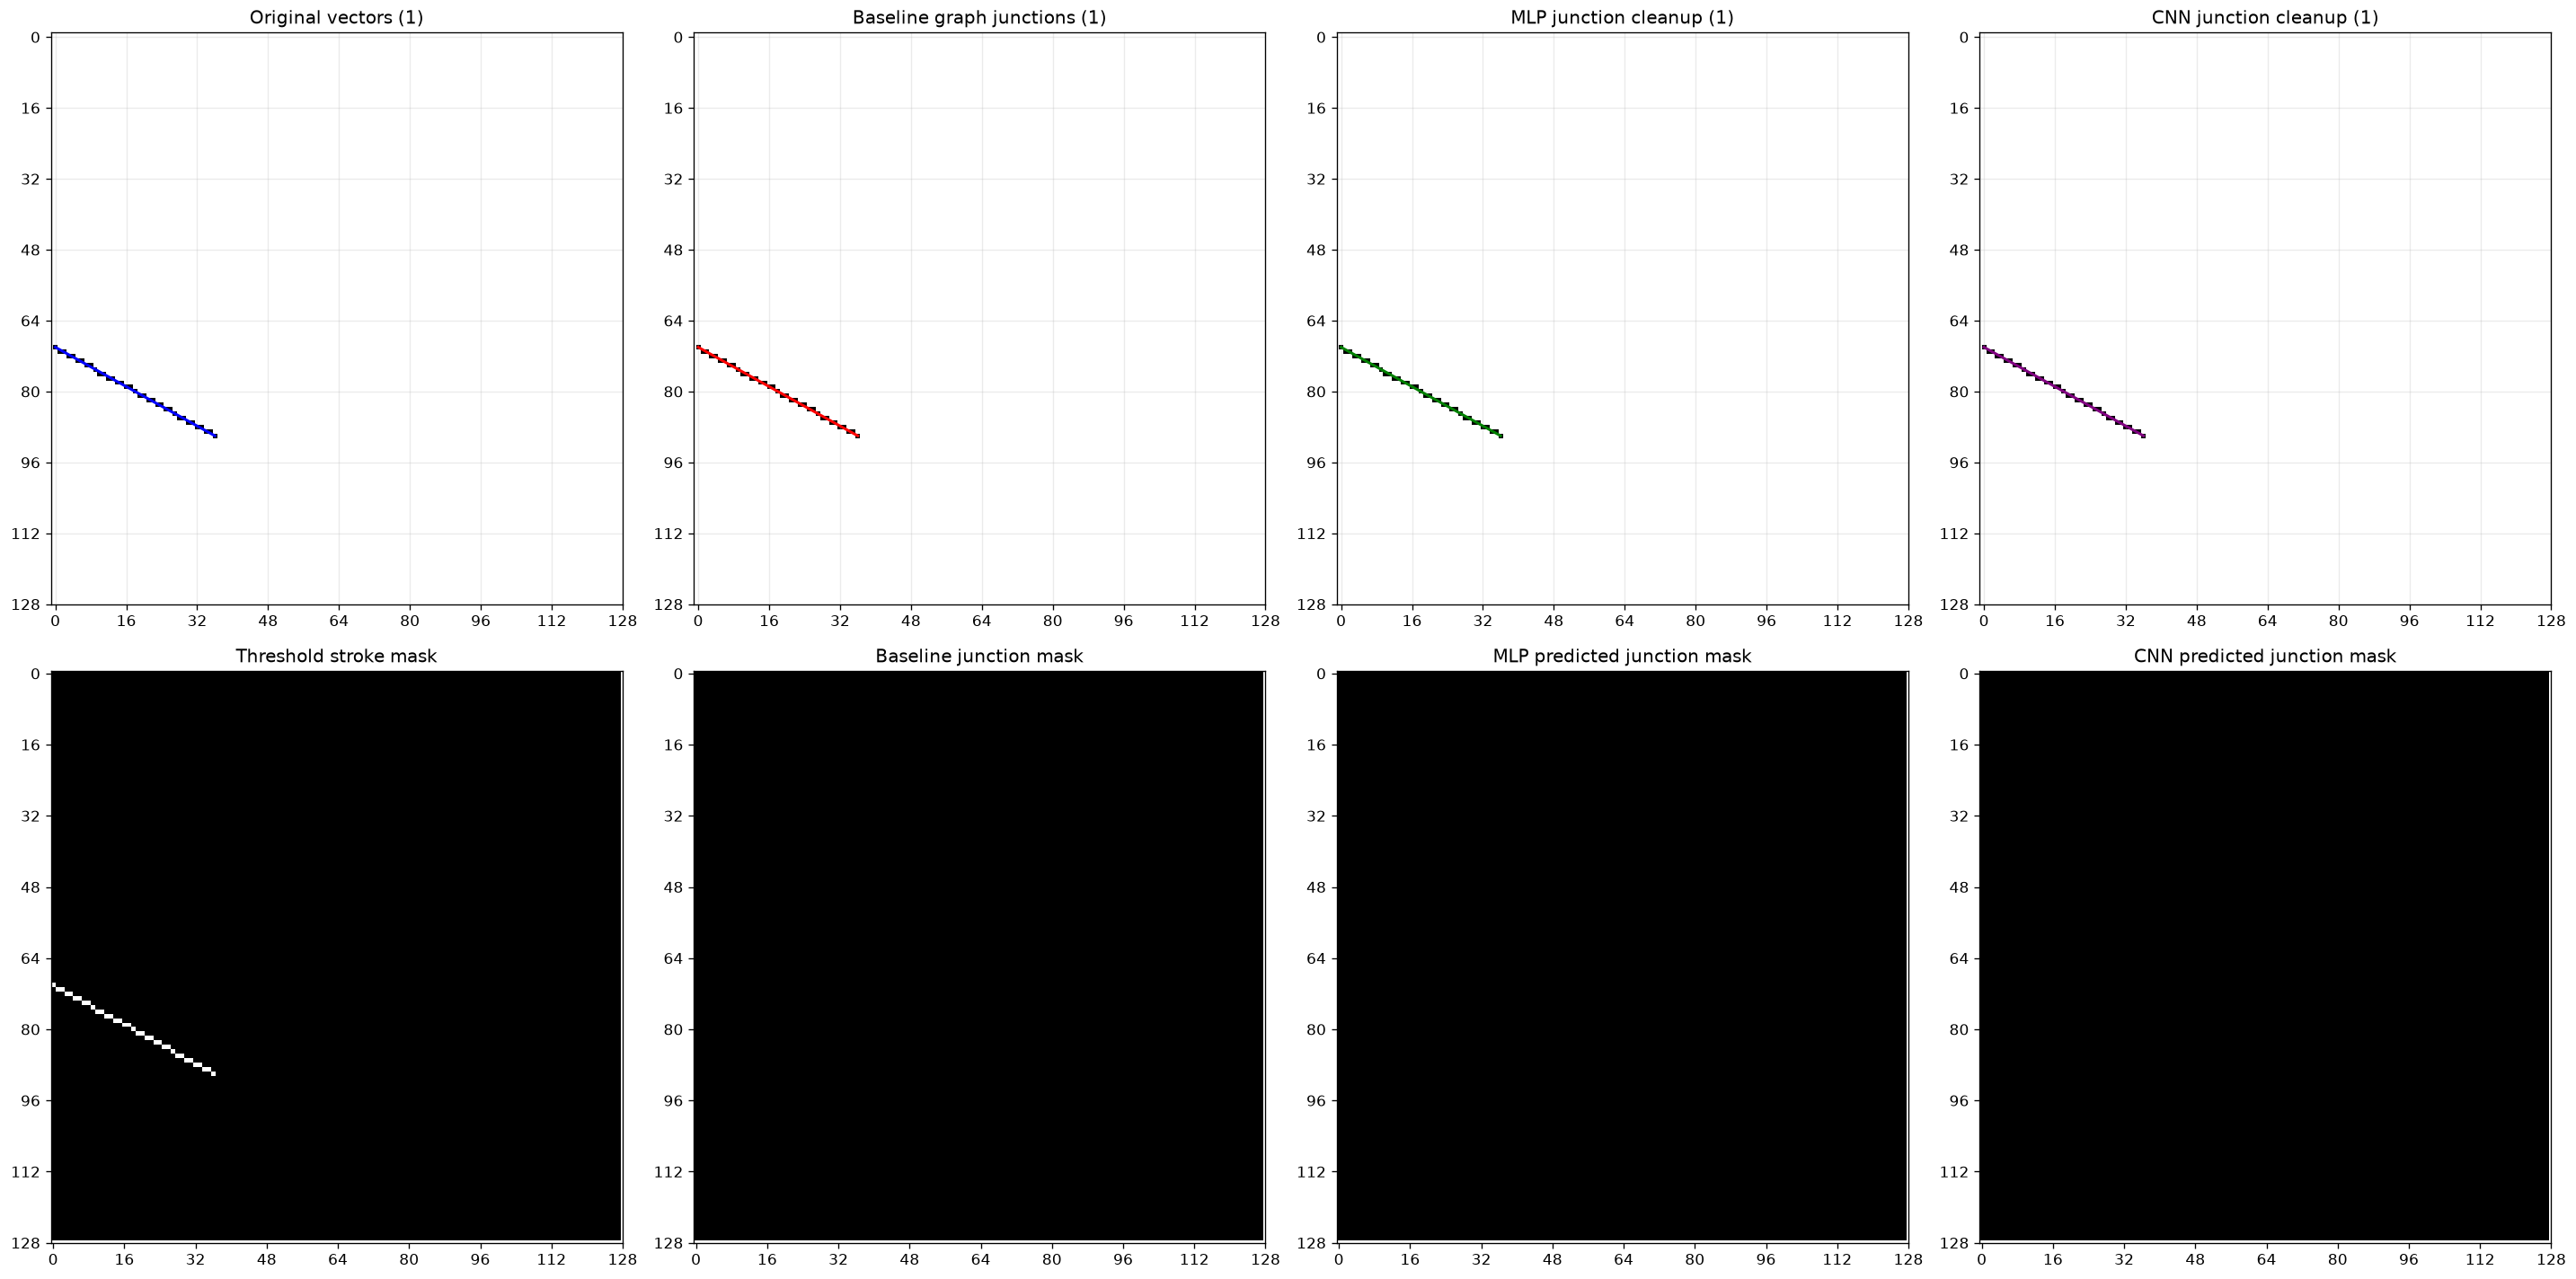

Sample 72


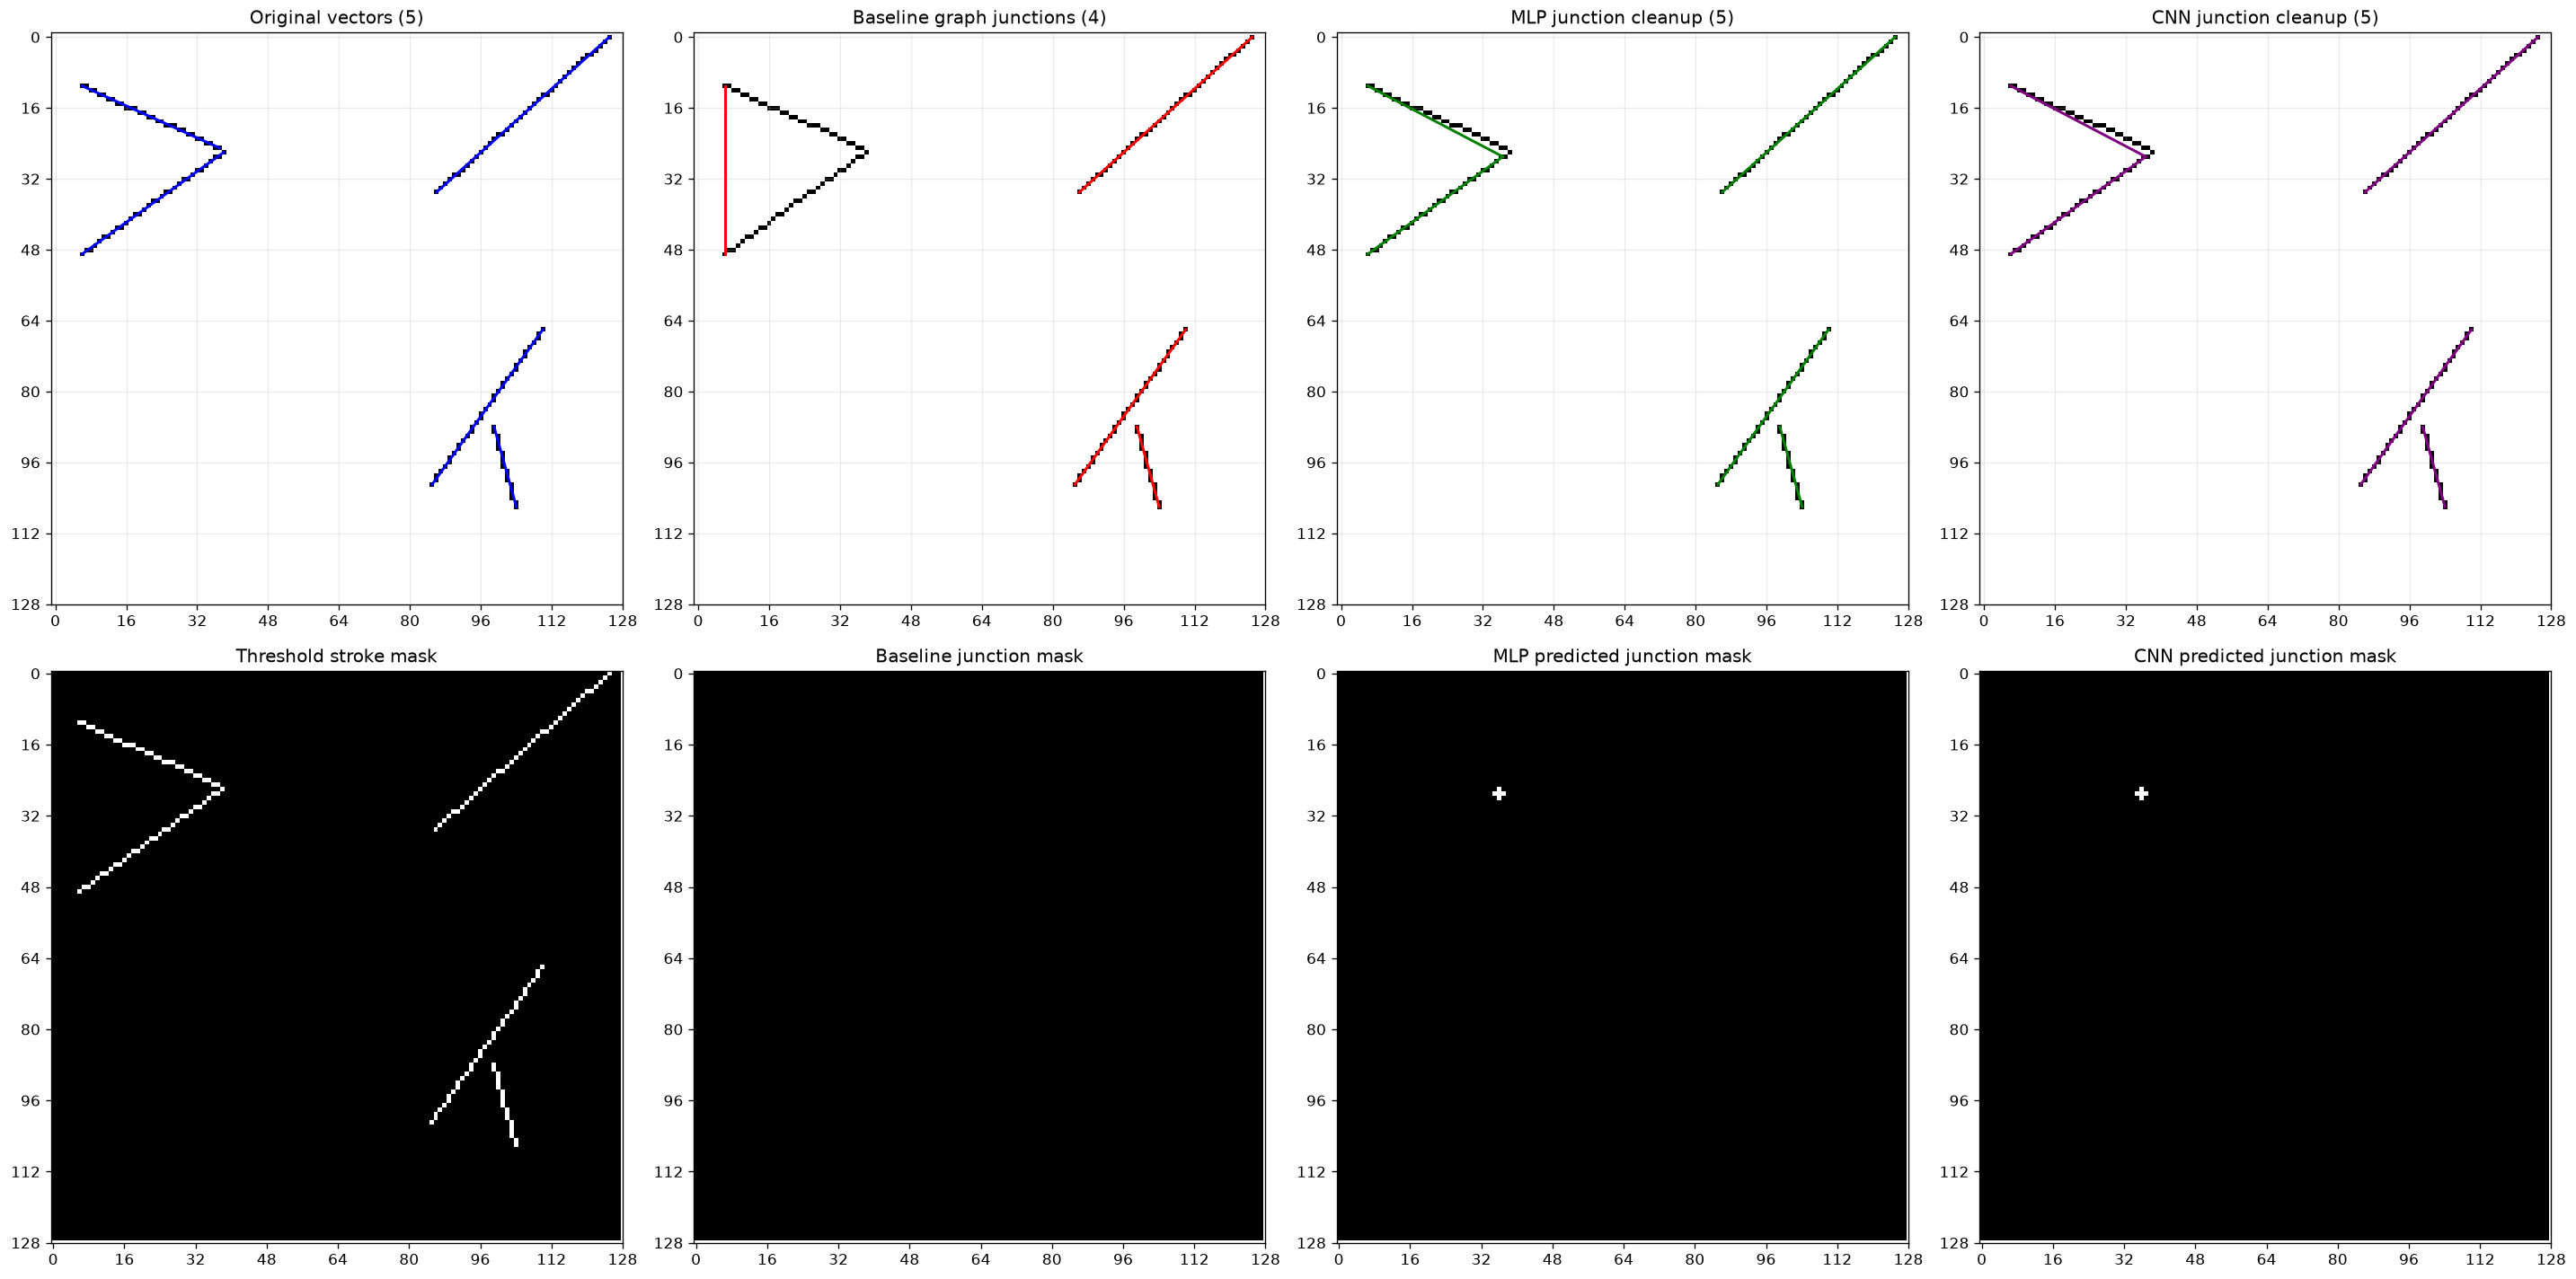

Sample 6


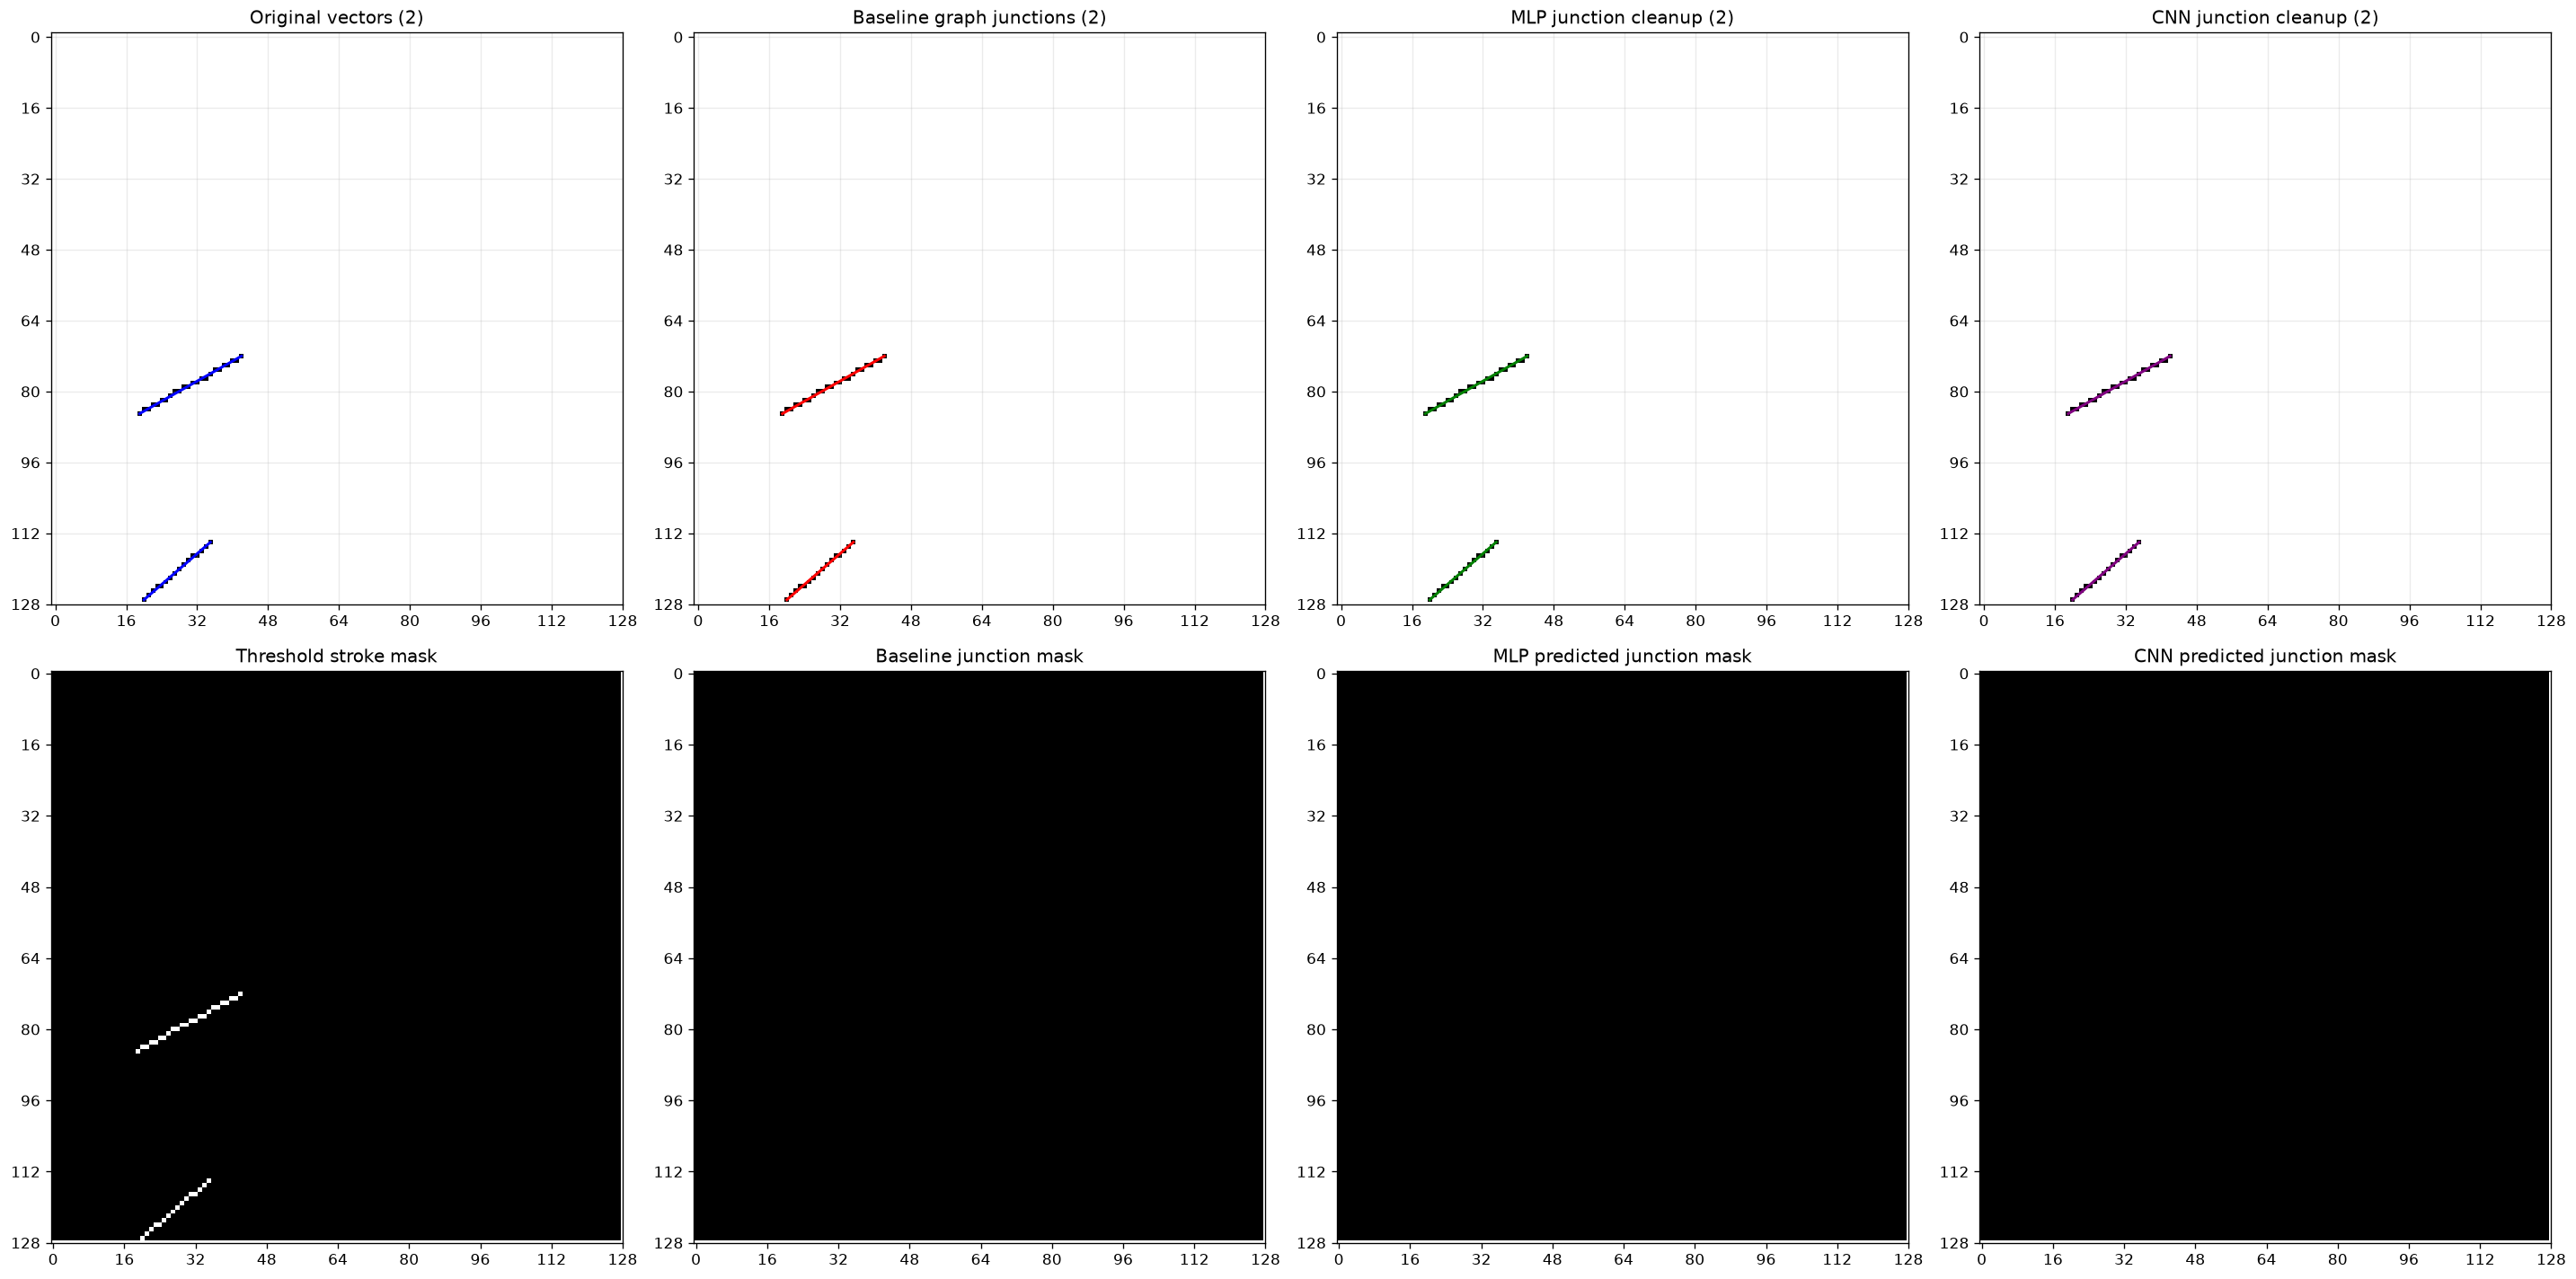

Sample 12


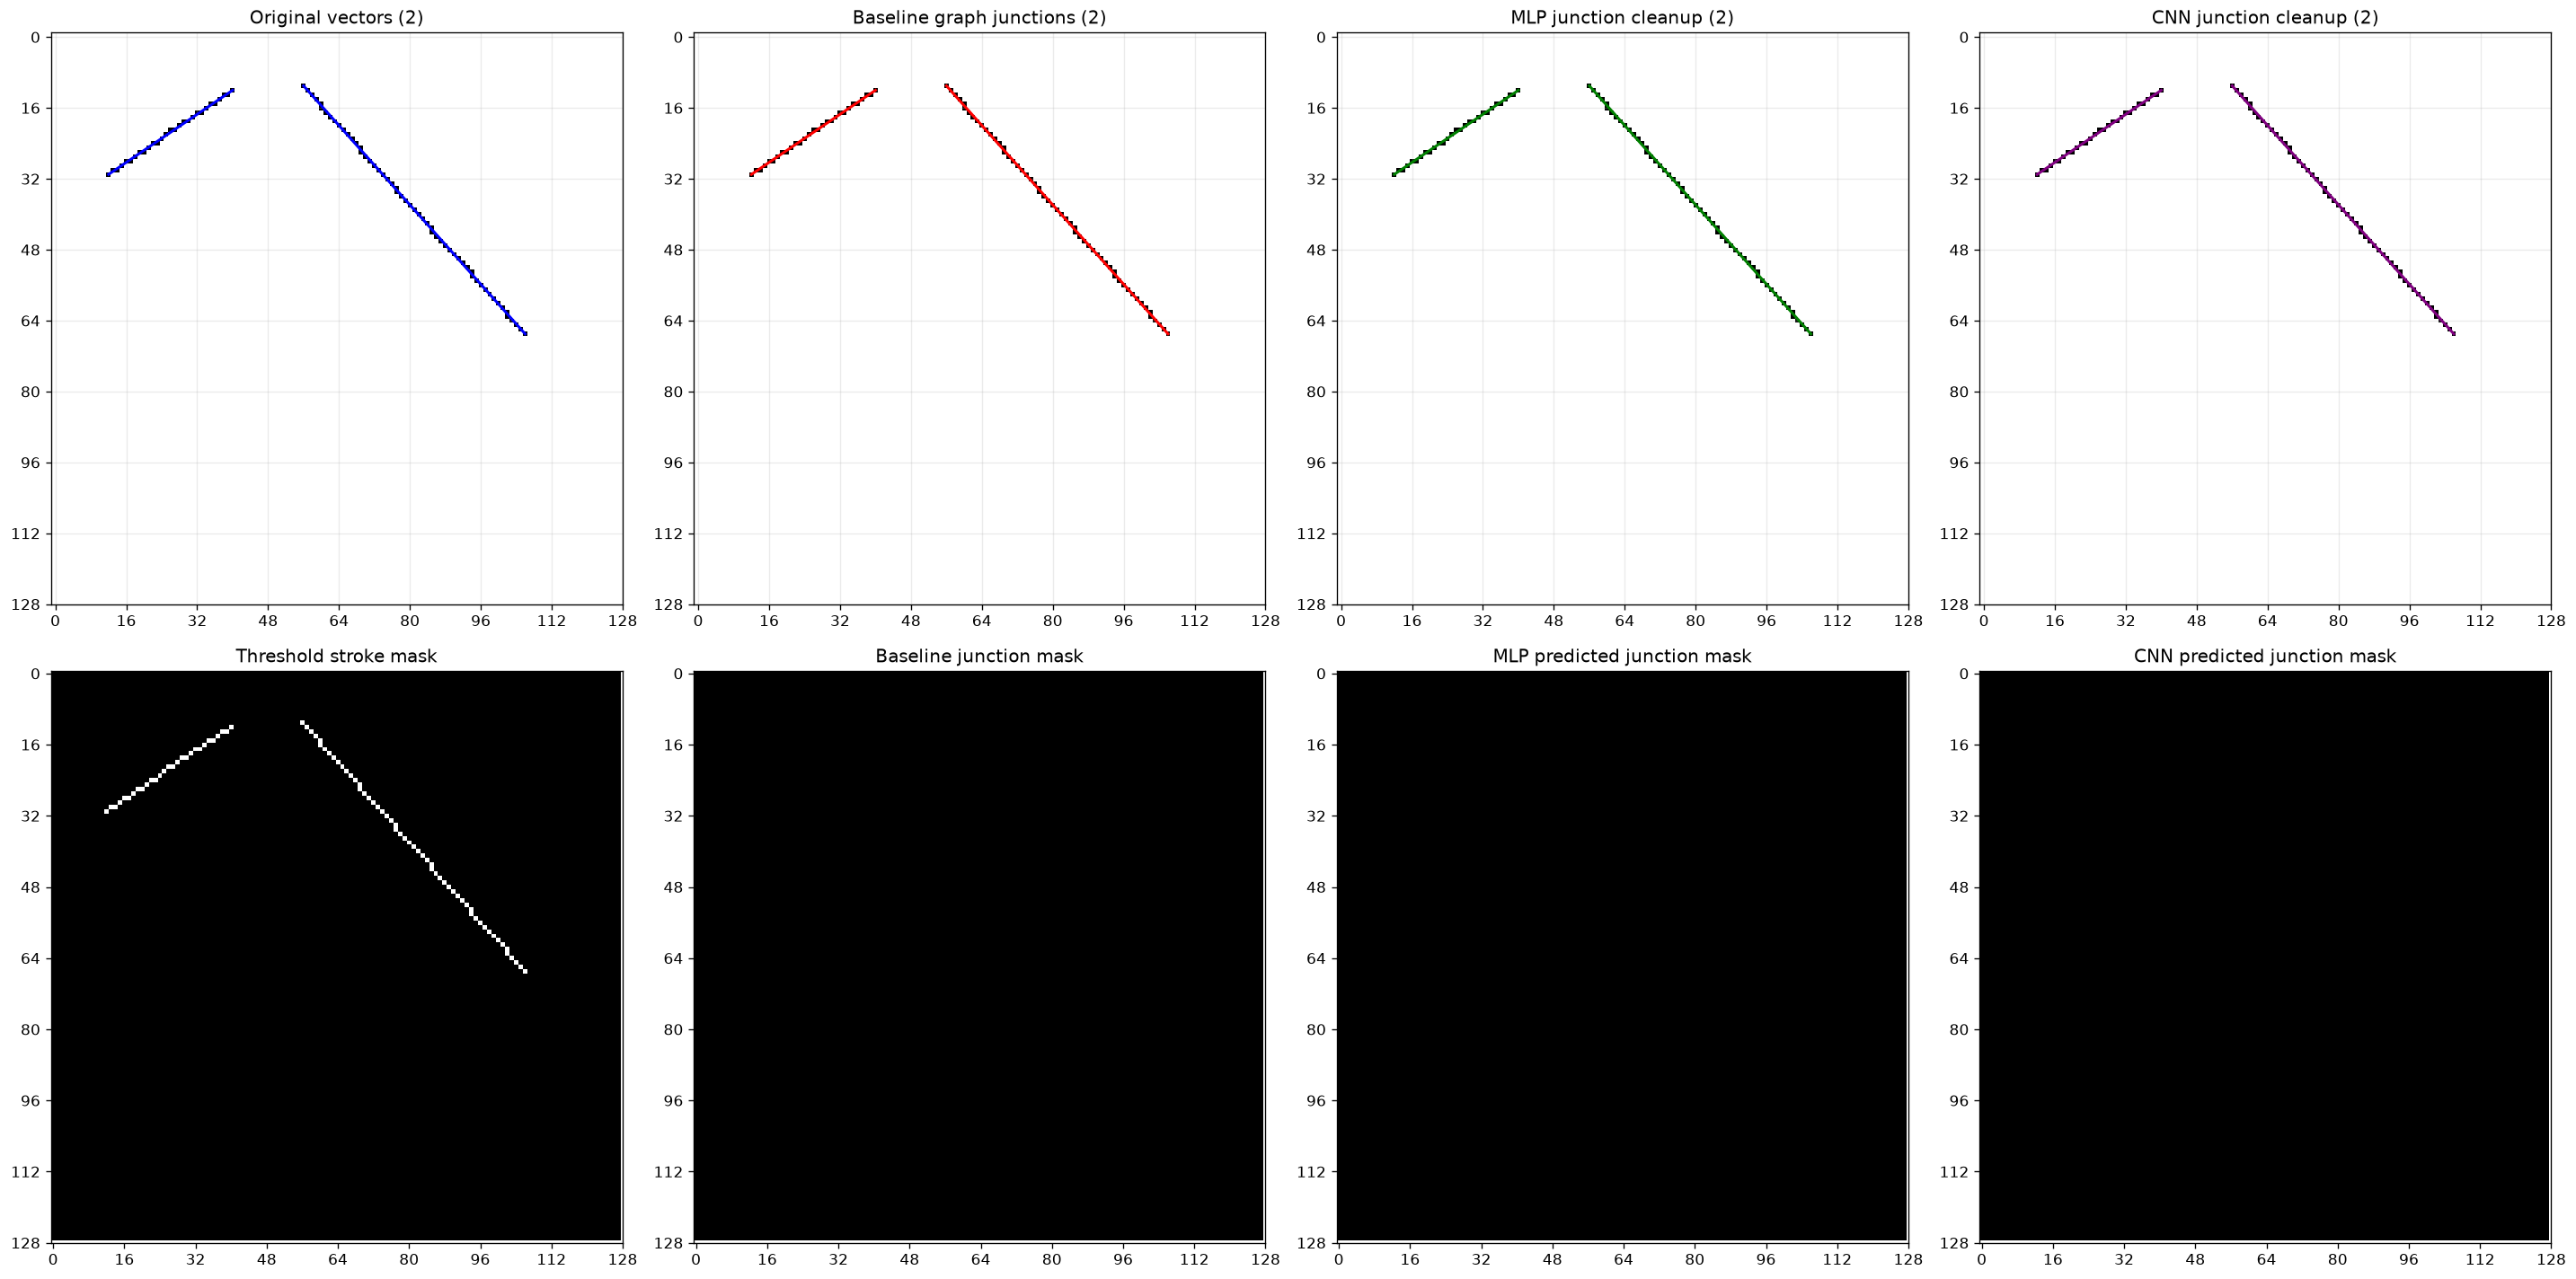

In [8]:
def draw_vectors(ax, image, vectors, title, colour='red'):
    ax.imshow(image, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    for x0, y0, x1, y1 in vectors:
        ax.plot([x0, x1], [y0, y1], color=colour, linewidth=1.8)
    ax.set_title(title)
    ax.set_xlim(-1, IMG_SIZE)
    ax.set_ylim(IMG_SIZE, -1)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.25)


def show_result(idx):
    image = test_images[idx]
    original_vectors = test_vectors[idx]
    base_vectors, base_debug = reconstruct_vectors_from_image(image, method='baseline')
    mlp_vectors, mlp_debug = reconstruct_vectors_from_image(image, method='mlp')
    cnn_vectors, cnn_debug = reconstruct_vectors_from_image(image, method='cnn')

    fig, ax = plt.subplots(2, 4, figsize=(24, 12), dpi=120)

    draw_vectors(ax[0,0], image, original_vectors, f'Original vectors ({len(original_vectors)})', 'blue')
    draw_vectors(ax[0,1], image, base_vectors, f'Baseline graph junctions ({len(base_vectors)})', 'red')
    draw_vectors(ax[0,2], image, mlp_vectors, f'MLP junction cleanup ({len(mlp_vectors)})', 'green')
    draw_vectors(ax[0,3], image, cnn_vectors, f'CNN junction cleanup ({len(cnn_vectors)})', 'purple')

    ax[1,0].imshow(base_debug['stroke'], cmap='gray', interpolation='nearest')
    ax[1,0].set_title('Threshold stroke mask')
    ax[1,1].imshow(base_debug['junction_mask'], cmap='gray', interpolation='nearest')
    ax[1,1].set_title('Baseline junction mask')
    ax[1,2].imshow(mlp_debug['junction_mask'], cmap='gray', interpolation='nearest')
    ax[1,2].set_title('MLP predicted junction mask')
    ax[1,3].imshow(cnn_debug['junction_mask'], cmap='gray', interpolation='nearest')
    ax[1,3].set_title('CNN predicted junction mask')

    for a in ax.ravel():
        a.set_xticks(np.arange(0, IMG_SIZE + 1, 16))
        a.set_yticks(np.arange(0, IMG_SIZE + 1, 16))
    plt.tight_layout()
    plt.show()


random_indices = random.sample(range(N_TEST), 10)
print('Random sample indices:', random_indices)

for idx in random_indices:
    print('=' * 100)
    print(f'Sample {idx}')
    show_result(idx)

## 8. SVG export for visual inspection

Each SVG has separate layers:

- `original_vectors` = blue
- `baseline_vectors` = red
- `mlp_vectors` = green
- `cnn_vectors` = purple

You can open these SVGs in Inkscape, Illustrator, a browser, or most CAD/vector tools.

In [9]:
import xml.etree.ElementTree as ET

EXPORT_DIR = Path('vector_exports_junction_ml')
EXPORT_DIR.mkdir(exist_ok=True)


def add_svg_layer(svg, layer_id, vectors, colour):
    layer = ET.SubElement(svg, 'g', {
        'id': layer_id,
        'stroke': colour,
        'stroke-width': '1',
        'fill': 'none',
        'stroke-linecap': 'round',
    })
    for x0, y0, x1, y1 in vectors:
        ET.SubElement(layer, 'line', {
            'x1': f'{x0:.3f}', 'y1': f'{y0:.3f}',
            'x2': f'{x1:.3f}', 'y2': f'{y1:.3f}',
        })


def export_sample_svg(idx, filename=None):
    image = test_images[idx]
    original_vectors = test_vectors[idx]
    base_vectors, _ = reconstruct_vectors_from_image(image, method='baseline')
    mlp_vectors, _ = reconstruct_vectors_from_image(image, method='mlp')
    cnn_vectors, _ = reconstruct_vectors_from_image(image, method='cnn')

    if filename is None:
        filename = EXPORT_DIR / f'sample_{idx}_junction_ml_compare.svg'

    scale = 6
    svg = ET.Element('svg', {
        'xmlns': 'http://www.w3.org/2000/svg',
        'width': str(IMG_SIZE * scale),
        'height': str(IMG_SIZE * scale),
        'viewBox': f'0 0 {IMG_SIZE} {IMG_SIZE}',
    })

    ET.SubElement(svg, 'rect', {
        'x': '0', 'y': '0',
        'width': str(IMG_SIZE),
        'height': str(IMG_SIZE),
        'fill': 'white',
    })

    add_svg_layer(svg, 'original_vectors', original_vectors, 'blue')
    add_svg_layer(svg, 'baseline_vectors', base_vectors, 'red')
    add_svg_layer(svg, 'mlp_vectors', mlp_vectors, 'green')
    add_svg_layer(svg, 'cnn_vectors', cnn_vectors, 'purple')

    tree = ET.ElementTree(svg)
    tree.write(filename, encoding='utf-8', xml_declaration=True)

    print(f'Exported sample {idx}')
    print(f'Original vectors: {len(original_vectors)}')
    print(f'Baseline vectors: {len(base_vectors)}')
    print(f'MLP vectors:      {len(mlp_vectors)}')
    print(f'CNN vectors:      {len(cnn_vectors)}')
    print(f'Saved to: {filename}')
    return filename

exported_files = []
for idx in random_indices:
    exported_files.append(export_sample_svg(idx))

exported_files

Exported sample 2
Original vectors: 1
Baseline vectors: 1
MLP vectors:      1
CNN vectors:      1
Saved to: vector_exports_junction_ml\sample_2_junction_ml_compare.svg
Exported sample 24
Original vectors: 2
Baseline vectors: 2
MLP vectors:      2
CNN vectors:      2
Saved to: vector_exports_junction_ml\sample_24_junction_ml_compare.svg
Exported sample 44
Original vectors: 1
Baseline vectors: 1
MLP vectors:      1
CNN vectors:      1
Saved to: vector_exports_junction_ml\sample_44_junction_ml_compare.svg
Exported sample 43
Original vectors: 4
Baseline vectors: 4
MLP vectors:      4
CNN vectors:      4
Saved to: vector_exports_junction_ml\sample_43_junction_ml_compare.svg
Exported sample 15
Original vectors: 4
Baseline vectors: 4
MLP vectors:      4
CNN vectors:      4
Saved to: vector_exports_junction_ml\sample_15_junction_ml_compare.svg
Exported sample 77
Original vectors: 1
Baseline vectors: 1
MLP vectors:      1
CNN vectors:      1
Saved to: vector_exports_junction_ml\sample_77_juncti

[WindowsPath('vector_exports_junction_ml/sample_2_junction_ml_compare.svg'),
 WindowsPath('vector_exports_junction_ml/sample_24_junction_ml_compare.svg'),
 WindowsPath('vector_exports_junction_ml/sample_44_junction_ml_compare.svg'),
 WindowsPath('vector_exports_junction_ml/sample_43_junction_ml_compare.svg'),
 WindowsPath('vector_exports_junction_ml/sample_15_junction_ml_compare.svg'),
 WindowsPath('vector_exports_junction_ml/sample_77_junction_ml_compare.svg'),
 WindowsPath('vector_exports_junction_ml/sample_16_junction_ml_compare.svg'),
 WindowsPath('vector_exports_junction_ml/sample_72_junction_ml_compare.svg'),
 WindowsPath('vector_exports_junction_ml/sample_6_junction_ml_compare.svg'),
 WindowsPath('vector_exports_junction_ml/sample_12_junction_ml_compare.svg')]

# Final evaluation: F1, IoU, precision/recall, vector deviation

In [10]:
import pandas as pd
import numpy as np

METHODS = ["baseline", "mlp", "cnn"]


def raster_metrics(true_raster, pred_raster):
    true = true_raster < 0.5
    pred = pred_raster < 0.5

    tp = np.logical_and(true, pred).sum()
    fp = np.logical_and(~true, pred).sum()
    fn = np.logical_and(true, ~pred).sum()
    tn = np.logical_and(~true, ~pred).sum()

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    iou = tp / (tp + fp + fn + 1e-9)
    accuracy = (tp + tn) / (tp + fp + fn + tn + 1e-9)

    return precision, recall, f1, iou, accuracy


def endpoint_distance(a, b):
    ax0, ay0, ax1, ay1 = a
    bx0, by0, bx1, by1 = b

    d1 = np.hypot(ax0 - bx0, ay0 - by0) + np.hypot(ax1 - bx1, ay1 - by1)
    d2 = np.hypot(ax0 - bx1, ay0 - by1) + np.hypot(ax1 - bx0, ay1 - by0)

    return min(d1, d2) / 2


results = []

for method in METHODS:
    print(f"Evaluating {method}")

    for idx, (image, true_vectors) in enumerate(zip(test_images, test_vectors)):

        pred_vectors, debug = reconstruct_vectors_from_image(
            image,
            method=method
        )

        pred_raster = rasterise_vectors(pred_vectors, IMG_SIZE)

        precision, recall, f1, iou, accuracy = raster_metrics(
            image,
            pred_raster
        )

        if len(true_vectors) > 0 and len(pred_vectors) > 0:
            deviations = []

            for gt in true_vectors:
                nearest = min(
                    endpoint_distance(gt, pred)
                    for pred in pred_vectors
                )
                deviations.append(nearest)

            endpoint_deviation = np.mean(deviations)
        else:
            endpoint_deviation = np.nan

        results.append({
            "method": method,
            "sample": idx,
            "true_vectors": len(true_vectors),
            "pred_vectors": len(pred_vectors),
            "vector_count_error": abs(len(true_vectors) - len(pred_vectors)),
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "iou": iou,
            "accuracy": accuracy,
            "endpoint_deviation_px": endpoint_deviation,
        })


results_df = pd.DataFrame(results)

summary_df = (
    results_df
    .groupby("method")
    .mean(numeric_only=True)
    .sort_values("f1", ascending=False)
    .round(4)
)

print("\nAverage method comparison")
display(summary_df)

print("\nPer-sample results")
display(results_df)

Evaluating baseline
Evaluating mlp
Evaluating cnn

Average method comparison


,sample,true_vectors,pred_vectors,vector_count_error,precision,recall,f1,iou,accuracy,endpoint_deviation_px
method,,,,,,,,,,
baseline,39.5,3.0,3.7625,0.7875,0.9304,0.9274,0.9288,0.8826,0.9984,1.7173
cnn,39.5,3.0,3.7875,0.7875,0.9242,0.9216,0.9229,0.8744,0.9982,1.6985
mlp,39.5,3.0,3.8125,0.8125,0.9187,0.9157,0.9172,0.8677,0.9981,1.6964



Per-sample results


,method,sample,true_vectors,pred_vectors,vector_count_error,precision,recall,f1,iou,accuracy,endpoint_deviation_px
0,baseline,0,2,2,0,0.661290,0.661290,0.661290,0.493976,0.997437,0.000000
1,baseline,1,4,9,5,0.772000,0.768924,0.770459,0.626623,0.992981,8.748710
2,baseline,2,1,1,0,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
3,baseline,3,2,2,0,0.985816,0.985816,0.985816,0.972028,0.999756,0.000000
4,baseline,4,4,6,2,0.971831,0.971831,0.971831,0.945205,0.999512,4.112703
...,...,...,...,...,...,...,...,...,...,...,...
235,cnn,75,1,1,0,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
236,cnn,76,5,7,2,0.833333,0.817308,0.825243,0.702479,0.993408,3.565314
237,cnn,77,1,1,0,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
238,cnn,78,5,10,5,0.740876,0.730216,0.735507,0.581662,0.991089,8.417651


# Threshold sweep for MLP and CNN junction confidence

In [14]:
ML_THRESHOLDS = [0.80, 0.85, 0.90, 0.95, 0.98]

sweep_rows = []

for threshold in ML_THRESHOLDS:
    print("=" * 80)
    print(f"Testing threshold: {threshold}")

    # overwrite the default thresholds used by the functions
    predict_junction_mask_mlp.__defaults__ = (mlp, threshold)
    predict_junction_mask_cnn.__defaults__ = (cnn, threshold)

    for method in ["mlp", "cnn"]:
        for idx, (image, true_vectors) in enumerate(zip(test_images, test_vectors)):

            pred_vectors, debug = reconstruct_vectors_from_image(
                image,
                method=method
            )

            pred_raster = rasterise_vectors(pred_vectors, IMG_SIZE)

            precision, recall, f1, iou, accuracy = raster_metrics(
                image,
                pred_raster
            )

            sweep_rows.append({
                "method": method,
                "threshold": threshold,
                "sample": idx,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "iou": iou,
                "accuracy": accuracy,
                "pred_vectors": len(pred_vectors),
                "true_vectors": len(true_vectors),
                "vector_count_error": abs(len(true_vectors) - len(pred_vectors)),
            })

sweep_df = pd.DataFrame(sweep_rows)

sweep_summary = (
    sweep_df
    .groupby(["method", "threshold"], as_index=False)
    .mean(numeric_only=True)
    .sort_values("f1", ascending=False)
    .round(4)
)

display(sweep_summary)
display(sweep_df)

Testing threshold: 0.8
Testing threshold: 0.85
Testing threshold: 0.9
Testing threshold: 0.95
Testing threshold: 0.98


,method,threshold,sample,precision,recall,f1,iou,accuracy,pred_vectors,true_vectors,vector_count_error
5,mlp,0.80,39.5,0.9278,0.9248,0.9262,0.8787,0.9982,3.8875,3.0,0.8875
0,cnn,0.80,39.5,0.9257,0.9227,0.9242,0.8760,0.9982,3.7625,3.0,0.7625
2,cnn,0.90,39.5,0.9242,0.9216,0.9229,0.8744,0.9982,3.7875,3.0,0.7875
1,cnn,0.85,39.5,0.9217,0.9189,0.9203,0.8703,0.9981,3.7625,3.0,0.7625
6,mlp,0.85,39.5,0.9196,0.9165,0.9180,0.8684,0.9981,3.8500,3.0,0.8500
7,mlp,0.90,39.5,0.9187,0.9157,0.9172,0.8677,0.9981,3.8125,3.0,0.8125
9,mlp,0.98,39.5,0.9195,0.9141,0.9167,0.8671,0.9981,3.8500,3.0,0.8750
8,mlp,0.95,39.5,0.9175,0.9144,0.9159,0.8669,0.9981,3.8000,3.0,0.8000
3,cnn,0.95,39.5,0.9161,0.9107,0.9132,0.8618,0.9980,3.7750,3.0,0.8000
4,cnn,0.98,39.5,0.9159,0.9106,0.9131,0.8646,0.9980,3.7500,3.0,0.7750


,method,threshold,sample,precision,recall,f1,iou,accuracy,pred_vectors,true_vectors,vector_count_error
0,mlp,0.80,0,0.661290,0.661290,0.661290,0.493976,0.997437,2,2,0
1,mlp,0.80,1,0.594378,0.589641,0.592000,0.420455,0.987549,9,4,5
2,mlp,0.80,2,1.000000,1.000000,1.000000,1.000000,1.000000,1,1,0
3,mlp,0.80,3,0.985816,0.985816,0.985816,0.972028,0.999756,2,2,0
4,mlp,0.80,4,0.971831,0.971831,0.971831,0.945205,0.999512,6,4,2
...,...,...,...,...,...,...,...,...,...,...,...
795,cnn,0.98,75,1.000000,1.000000,1.000000,1.000000,1.000000,1,1,0
796,cnn,0.98,76,0.827362,0.814103,0.820679,0.695890,0.993225,7,5,2
797,cnn,0.98,77,1.000000,1.000000,1.000000,1.000000,1.000000,1,1,0
798,cnn,0.98,78,0.617391,0.510791,0.559055,0.387978,0.986328,10,5,5


## Notes for tuning

The most useful settings to tune are:

```python
JUNCTION_RADIUS = 3
MIN_VECTOR_LENGTH = 3.0
MAX_MERGE_PASSES = 2
```
max merge passes = 4 made for worse data.


**Min line length changed to 2, seemed to help CNN**

For fewer tiny lines at junctions, increase `JUNCTION_RADIUS` slightly or increase `MIN_VECTOR_LENGTH`.

For fewer gaps at junctions, reduce `JUNCTION_RADIUS` slightly or lower the prediction threshold inside:

```python
predict_junction_mask_mlp(image, threshold=0.5)
predict_junction_mask_cnn(image, threshold=0.5)
```

Tested threshold up to 0.9 - still produced worse results than baseline